# Preprocess

## 确认h5文件结构

In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
import h5py

data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
h5_path =data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"

# ---- 1. 查看 h5 文件内部结构 ----
print("=== h5 文件结构 ===")
with h5py.File(h5_path, 'r') as f:
    def print_structure(name, obj):
        print(f"  {name}: {type(obj).__name__}")
    f.visititems(print_structure)

# ---- 2. 读取数据 ----
adata = sc.read_10x_h5(h5_path, gex_only=True)
adata.var_names_make_unique()
print(f"\n数据规模: {adata.shape[0]} cells × {adata.shape[1]} genes")

# ---- 3. 检查 barcode 后缀（关键！）----
barcodes = adata.obs_names.tolist()
suffixes = [bc.split('-')[-1] for bc in barcodes]
suffix_counts = pd.Series(suffixes).value_counts().sort_index()
print(f"\nBarcode 后缀分布（每个后缀对应一个样本）:")
print(suffix_counts)
# 如果看到 -1, -2, -3... 说明是多样本 aggr 文件
# 如果只有 -1，说明是单样本

# ---- 4. 检查是否有伴随的 metadata 文件 ----
import os
data_dir = os.path.dirname(h5_path)
print(f"\n同目录下的文件:")
for f in os.listdir(data_dir):
    print(f"  {f}")

=== h5 文件结构 ===
  matrix: Group
  matrix/barcodes: Dataset
  matrix/data: Dataset
  matrix/features: Group
  matrix/features/_all_tag_keys: Dataset
  matrix/features/feature_type: Dataset
  matrix/features/genome: Dataset
  matrix/features/id: Dataset
  matrix/features/interval: Dataset
  matrix/features/name: Dataset
  matrix/indices: Dataset
  matrix/indptr: Dataset
  matrix/shape: Dataset


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



数据规模: 33459 cells × 32286 genes

Barcode 后缀分布（每个后缀对应一个样本）:
1     1829
10    4561
11    1226
12    1280
2     1821
3     1522
4     1688
5      664
6      641
7     6652
8     7208
9     4367
Name: count, dtype: int64

同目录下的文件:
  process
  Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5
  Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_atac_fragments.tsv.gz


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 确认数据信息

In [10]:
"""
identify_samples.py
通过基因表达特征推断每个 barcode 后缀对应的样本信息
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import h5py, os

######################################################################
# 参数设置
######################################################################
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
h5_path =data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"

output_path = data_root + "process/"
os.makedirs(output_path, exist_ok=True)

######################################################################
# Step 1: 读取数据
######################################################################
adata = sc.read_10x_h5(h5_path, gex_only=True)
adata.var_names_make_unique()
print(f"数据: {adata.shape[0]} cells × {adata.shape[1]} genes")

# 提取后缀
adata.obs['suffix'] = [bc.split('-')[-1] for bc in adata.obs_names]

# 每个后缀的细胞数
suffix_counts = adata.obs['suffix'].value_counts().sort_index()
print("\n各后缀细胞数:")
print(suffix_counts)

######################################################################
# Step 2: 查看基因名中有没有人类 APP 相关基因
######################################################################
# CRND8 转基因小鼠高表达人类 APP，数据集使用了包含人类 APP 的自定义参考
app_genes = [g for g in adata.var_names if 'App' in g or 'APP' in g]
print(f"\n数据中的 APP 相关基因: {app_genes}")

# 同时看看 Amyloid 相关基因
amyloid_genes = [g for g in adata.var_names if any(
    kw in g for kw in ['App', 'APP', 'Aplp', 'Adam10', 'Bace1'])]
print(f"Amyloid 通路基因: {amyloid_genes}")

######################################################################
# Step 3: 基础归一化
######################################################################
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

######################################################################
# Step 4: 计算每个后缀的特征表达
######################################################################
# 每个后缀的平均 App 表达（CRND8 应该显著高于 WT）
results = []

for suffix in sorted(adata.obs['suffix'].unique()):
    mask = adata.obs['suffix'] == suffix
    sub = adata[mask]
    n_cells = mask.sum()
    
    # APP 表达（区分 WT vs CRND8）
    app_expr = 0
    for g in app_genes:
        if g in adata.var_names:
            vals = sub[:, g].X
            if hasattr(vals, 'toarray'):
                vals = vals.toarray().flatten()
            app_expr = float(np.mean(vals))
            break
    
    # 微小胶质细胞激活标记（区分疾病阶段/年龄）
    # DAM 基因在老年 CRND8 小鼠中高表达
    dam_genes = ['Trem2', 'Cst7', 'Lpl', 'Spp1', 'Cd9']
    dam_expr = 0
    for g in dam_genes:
        if g in adata.var_names:
            vals = sub[:, g].X
            if hasattr(vals, 'toarray'):
                vals = vals.toarray().flatten()
            dam_expr += float(np.mean(vals))
    
    # 年龄相关基因（老年标记）
    aging_genes = ['Cdkn1a', 'Cxcl10', 'B2m', 'H2-D1']
    aging_expr = 0
    for g in aging_genes:
        if g in adata.var_names:
            vals = sub[:, g].X
            if hasattr(vals, 'toarray'):
                vals = vals.toarray().flatten()
            aging_expr += float(np.mean(vals))
    
    # 平均基因数（年龄相关细胞质量）
    mean_genes = float(sub.obs['n_genes_by_counts'].mean()) \
        if 'n_genes_by_counts' in sub.obs.columns else 0
    
    results.append({
        'suffix': suffix,
        'n_cells': n_cells,
        'app_expr': app_expr,
        'dam_expr': dam_expr,
        'aging_expr': aging_expr,
    })

df = pd.DataFrame(results).sort_values('suffix')
print("\n各后缀特征:")
print(df.to_string(index=False))

######################################################################
# Step 5: 聚类识别 WT vs CRND8
######################################################################
# APP 表达高的是 CRND8
app_values = df['app_expr'].values
if app_values.max() > 0:
    # 用中位数分界
    threshold = np.median(app_values)
    df['inferred_genotype'] = ['CRND8' if v > threshold else 'WT' 
                                for v in app_values]
    print(f"\nAPP 表达中位数: {threshold:.4f}")
    print("推断的基因型:")
    print(df[['suffix', 'n_cells', 'app_expr', 'inferred_genotype']].to_string(index=False))
else:
    print("\n[警告] APP 基因表达为 0，可能基因名不匹配")
    print("改用 DAM 基因区分老年 CRND8:")
    print(df[['suffix', 'n_cells', 'dam_expr', 'aging_expr']].to_string(index=False))

######################################################################
# Step 6: 可视化各后缀的表达分布
######################################################################
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(df['suffix'], df['n_cells'])
axes[0].set_title('Cell Count per Suffix')
axes[0].set_xlabel('Barcode Suffix')
axes[0].set_ylabel('N cells')

axes[1].bar(df['suffix'], df['app_expr'])
axes[1].set_title('Mean APP Expression\n(CRND8 should be higher)')
axes[1].set_xlabel('Barcode Suffix')

axes[2].bar(df['suffix'], df['dam_expr'])
axes[2].set_title('Mean DAM Score\n(higher in late-stage CRND8)')
axes[2].set_xlabel('Barcode Suffix')

plt.tight_layout()
plt.savefig(output_path + "suffix_characterization.png", dpi=150)
plt.close()
print(f"\n图已保存: {output_path}suffix_characterization.png")

######################################################################
# Step 7: 打印所有基因名中的 APP 相关项（诊断用）
######################################################################
print("\n=== 基因名诊断 ===")
print(f"总基因数: {adata.shape[1]}")
print(f"前 10 个基因: {list(adata.var_names[:10])}")
print(f"包含 'App' 的基因: {[g for g in adata.var_names if 'App' in g][:20]}")
print(f"包含 'Human' 或 'human' 的基因: {[g for g in adata.var_names if 'human' in g.lower()][:10]}")


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


数据: 33459 cells × 32286 genes

各后缀细胞数:
suffix
1     1829
10    4561
11    1226
12    1280
2     1821
3     1522
4     1688
5      664
6      641
7     6652
8     7208
9     4367
Name: count, dtype: int64

数据中的 APP 相关基因: ['Appl2', 'Appbp2', 'Appbp2os', 'Appl1', 'App', 'APP']
Amyloid 通路基因: ['Aplp1', 'Aplp2', 'Bace1', 'Adam10', 'Appl2', 'Appbp2', 'Appbp2os', 'Appl1', 'App', 'APP']

各后缀特征:
suffix  n_cells  app_expr  dam_expr  aging_expr
     1     1829  0.284642  0.609112    0.519731
    10     4561  0.353431  0.247637    0.137252
    11     1226  0.336657  0.310931    0.193268
    12     1280  0.312946  0.310382    0.170684
     2     1821  0.273406  0.697582    0.542407
     3     1522  0.388404  0.227362    0.140559
     4     1688  0.407095  0.282706    0.203315
     5      664  0.275081  0.460178    0.368622
     6      641  0.280920  0.615802    0.426093
     7     6652  0.315414  0.355883    0.228684
     8     7208  0.295004  0.370748    0.217403
     9     4367  0.360720  0.261403

## 信息修正

In [12]:
"""
identify_samples_v2.py
用人类 APP 转基因精确区分 CRND8 vs WT，用 DAM 基因排序年龄
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
h5_path =data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"

output_path = data_root + "process/"
os.makedirs(output_path, exist_ok=True)

adata = sc.read_10x_h5(h5_path, gex_only=True)
adata.var_names_make_unique()

# 提取后缀
adata.obs['suffix'] = [bc.split('-')[-1] for bc in adata.obs_names]

# 归一化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# ============================================================
# 关键：用 'APP'（全大写，人类转基因）区分 CRND8 vs WT
# ============================================================
# 确认 APP 存在
assert 'APP' in adata.var_names, "APP 基因不在数据中"
print(f"确认 'APP'（人类转基因）存在于数据中")

# 年龄相关基因：DAM（Disease-Associated Microglia）基因随 AD 进展升高
dam_genes     = [g for g in ['Trem2','Cst7','Lpl','Spp1','Cd9','Clec7a','Ccl3','Cxcl10'] 
                 if g in adata.var_names]
# 衰老标记基因
aging_genes   = [g for g in ['Cdkn1a','B2m','H2-D1','Cxcl10','Lgals3'] 
                 if g in adata.var_names]
# 早期活化小胶质：随年龄/疾病升高
micro_act     = [g for g in ['Cx3cr1','P2ry12','Csf1r','Hexb'] 
                 if g in adata.var_names]

print(f"DAM 基因: {dam_genes}")
print(f"衰老基因: {aging_genes}")

# ============================================================
# 按后缀计算特征
# ============================================================
results = []

for suffix in sorted(adata.obs['suffix'].unique(), key=int):
    mask = adata.obs['suffix'] == suffix
    sub = adata[mask]
    
    def mean_expr(genes):
        if not genes:
            return 0.0
        X = sub[:, genes].X
        if hasattr(X, 'toarray'):
            X = X.toarray()
        return float(np.mean(X))
    
    # 人类 APP 表达（CRND8 应该高）
    app_human = sub[:, 'APP'].X
    if hasattr(app_human, 'toarray'):
        app_human = app_human.toarray().flatten()
    app_human_mean = float(np.mean(app_human))
    app_human_pct  = float(np.mean(app_human > 0) * 100)  # 阳性细胞比例
    
    # 小鼠内源 App（WT 和 CRND8 都有）
    app_mouse = sub[:, 'App'].X
    if hasattr(app_mouse, 'toarray'):
        app_mouse = app_mouse.toarray().flatten()
    app_mouse_mean = float(np.mean(app_mouse))
    
    results.append({
        'suffix':          int(suffix),
        'n_cells':         mask.sum(),
        'APP_human_mean':  round(app_human_mean, 4),
        'APP_human_pct%':  round(app_human_pct, 1),
        'App_mouse_mean':  round(app_mouse_mean, 4),
        'DAM_score':       round(mean_expr(dam_genes), 4),
        'aging_score':     round(mean_expr(aging_genes), 4),
    })

df = pd.DataFrame(results).sort_values('suffix').reset_index(drop=True)
print("\n=== 各后缀特征 ===")
print(df.to_string(index=False))

# ============================================================
# 推断基因型：APP_human_pct% 高的是 CRND8
# ============================================================
# 画出 APP 人类转基因表达分布，找天然分界
app_vals = df['APP_human_pct%'].values
sorted_vals = np.sort(app_vals)
print(f"\nAPP_human_pct% 分布: min={sorted_vals.min():.1f}, "
      f"max={sorted_vals.max():.1f}, values={sorted_vals}")

# 找最大间隙作为 WT/CRND8 分界
gaps = np.diff(sorted_vals)
threshold_idx = np.argmax(gaps)
threshold = (sorted_vals[threshold_idx] + sorted_vals[threshold_idx + 1]) / 2
print(f"自动分界阈值: {threshold:.2f}%")

df['inferred_genotype'] = ['CRND8' if v > threshold else 'WT' 
                            for v in df['APP_human_pct%']]

# 在每个基因型内，按 DAM_score 排序推断时间点
time_points = [2.5, 5.7, 13.2, 17.9]

for geno in ['WT', 'CRND8']:
    sub_df = df[df['inferred_genotype'] == geno].sort_values('DAM_score').reset_index(drop=True)
    n = len(sub_df)
    print(f"\n{geno}: {n} 个样本（按 DAM_score 升序排列）")
    print(sub_df[['suffix','n_cells','APP_human_pct%','DAM_score','aging_score']].to_string(index=False))
    
    # 分配时间点
    if n <= 4:
        assigned_times = time_points[:n]
    else:
        # 超过4个说明有重复，均匀分配
        assigned_times = [time_points[min(i * 4 // n, 3)] for i in range(n)]
    
    df.loc[df['inferred_genotype'] == geno, 'inferred_age'] = assigned_times
    print(f"  分配时间点: {assigned_times}")

df['sample_id'] = df['inferred_genotype'] + '_' + df['inferred_age'].astype(str) + 'mo'
print("\n=== 最终样本映射表 ===")
print(df[['suffix','n_cells','inferred_genotype','inferred_age','sample_id',
          'APP_human_pct%','DAM_score']].to_string(index=False))

# ============================================================
# 保存映射表
# ============================================================
df.to_csv(output_path + "suffix_to_sample_mapping.csv", index=False)
print(f"\n映射表已保存: {output_path}suffix_to_sample_mapping.csv")

# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors = {'WT': '#4393C3', 'CRND8': '#D6604D'}
bar_colors = [colors[g] for g in df['inferred_genotype']]

# Panel 1: 人类 APP 表达（WT vs CRND8 分界）
ax = axes[0, 0]
bars = ax.bar(df['suffix'].astype(str), df['APP_human_pct%'], color=bar_colors)
ax.axhline(y=threshold, color='black', linestyle='--', linewidth=1.5, label=f'threshold={threshold:.1f}%')
ax.set_title('Human APP+ Cell % per Sample\n(CRND8 > threshold)')
ax.set_xlabel('Barcode Suffix')
ax.set_ylabel('% cells expressing human APP')
ax.legend()
from matplotlib.patches import Patch
legend_elements = [Patch(color=colors['WT'], label='WT'),
                   Patch(color=colors['CRND8'], label='CRND8')]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0],color='k',linestyle='--',label=f'threshold')],
          fontsize=9)

# Panel 2: DAM score（时间/疾病进展代理）
ax = axes[0, 1]
ax.bar(df['suffix'].astype(str), df['DAM_score'], color=bar_colors)
ax.set_title('DAM Gene Score per Sample\n(proxy for disease stage/age)')
ax.set_xlabel('Barcode Suffix')
ax.set_ylabel('Mean DAM gene expression')

# Panel 3: 细胞数
ax = axes[1, 0]
ax.bar(df['suffix'].astype(str), df['n_cells'], color=bar_colors)
ax.set_title('Cell Count per Suffix')
ax.set_xlabel('Barcode Suffix')
ax.set_ylabel('N cells')

# Panel 4: 样本映射结果
ax = axes[1, 1]
ax.axis('off')
table_data = df[['suffix','sample_id','n_cells']].values.tolist()
table = ax.table(
    cellText=table_data,
    colLabels=['Suffix','Sample ID','N cells'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax.set_title('Inferred Sample Identity', pad=20)

plt.tight_layout()
plt.savefig(output_path + "sample_identification.png", dpi=200, bbox_inches='tight')

print(f"图已保存: {output_path}sample_identification.png")


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


确认 'APP'（人类转基因）存在于数据中
DAM 基因: ['Trem2', 'Cst7', 'Lpl', 'Spp1', 'Cd9', 'Ccl3', 'Cxcl10']
衰老基因: ['Cdkn1a', 'B2m', 'H2-D1', 'Cxcl10', 'Lgals3']

=== 各后缀特征 ===
 suffix  n_cells  APP_human_mean  APP_human_pct%  App_mouse_mean  DAM_score  aging_score
      1     1829          0.8683            62.2          1.6878     0.0884       0.1067
      2     1821          0.9078            63.8          1.7263     0.1015       0.1120
      3     1522          0.6720            57.3          1.7816     0.0325       0.0285
      4     1688          0.6647            56.3          1.7311     0.0404       0.0419
      5      664          0.9917            67.6          1.6185     0.0660       0.0740
      6      641          1.0681            67.4          1.6289     0.0880       0.0867
      7     6652          0.0014             0.1          1.7889     0.0509       0.0463
      8     7208          0.0001             0.0          1.8186     0.0531       0.0438
      9     4367          0.0008           

## 验证信息

In [14]:
"""
assign_metadata_final.py
手动修正时间点分配 + 写入 metadata + 合并同时间点重复
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
h5_path =data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"

output_path = data_root + "process/"
os.makedirs(output_path, exist_ok=True)

# ============================================================
# Step 1: 读取数据
# ============================================================
adata = sc.read_10x_h5(h5_path, gex_only=True)
adata.var_names_make_unique()
adata.obs['suffix'] = [bc.split('-')[-1] for bc in adata.obs_names]

# ============================================================
# Step 2: 手动修正映射表
# （基于 APP_human_pct% + DAM_score + 细胞数综合判断）
# ============================================================
# 注意：suffix 5,6 细胞数少（~640），可能是某个特定时间点或质量问题
# 先用最保守的 DAM 排序方案，你可以根据后续 UMAP 验证后再调整

suffix_map = {
    # CRND8：按 DAM_score 从低到高对应 2.5 → 17.9 月
    '1': {'genotype': 'CRND8', 'age': 17.9, 'replicate': 1},
    '2': {'genotype': 'CRND8', 'age': 17.9, 'replicate': 2},
    '3': {'genotype': 'CRND8', 'age': 2.5,  'replicate': 1},
    '4': {'genotype': 'CRND8', 'age': 2.5,  'replicate': 2},
    '5': {'genotype': 'CRND8', 'age': 5.7,  'replicate': 1},
    '6': {'genotype': 'CRND8', 'age': 13.2, 'replicate': 1},
    # WT：细胞数大的 7,8 是 2.5mo（年轻小鼠细胞存活率最高）
    # 9,10 中等 → 5.7mo 和 13.2mo，11,12 最少 → 17.9mo
    '7':  {'genotype': 'WT', 'age': 2.5,  'replicate': 1},
    '8':  {'genotype': 'WT', 'age': 2.5,  'replicate': 2},
    '9':  {'genotype': 'WT', 'age': 5.7,  'replicate': 1},
    '10': {'genotype': 'WT', 'age': 13.2, 'replicate': 1},
    '11': {'genotype': 'WT', 'age': 17.9, 'replicate': 1},
    '12': {'genotype': 'WT', 'age': 17.9, 'replicate': 2},
}

# 写入 metadata
adata.obs['genotype']  = [suffix_map[s]['genotype']  for s in adata.obs['suffix']]
adata.obs['age']       = [suffix_map[s]['age']        for s in adata.obs['suffix']]
adata.obs['replicate'] = [suffix_map[s]['replicate']  for s in adata.obs['suffix']]
adata.obs['sample_id'] = [f"{suffix_map[s]['genotype']}_{suffix_map[s]['age']}mo_rep{suffix_map[s]['replicate']}"
                           for s in adata.obs['suffix']]

print("=== 样本分布 ===")
print(adata.obs.groupby(['genotype','age','replicate']).size().unstack(fill_value=0))

# ============================================================
# Step 3: QC 过滤
# ============================================================
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

n_before = adata.shape[0]
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 8000) &
    (adata.obs.pct_counts_mt < 20)
].copy()
print(f"\nQC 过滤: {n_before} → {adata.shape[0]} cells")

adata.layers['counts'] = adata.X.copy()

# ============================================================
# Step 4: 归一化 + 聚类（用于验证时间点分配）
# ============================================================
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key='sample_id')
sc.pp.pca(adata, n_comps=30)

# Harmony 批次校正（多样本必须做）
try:
    sc.external.pp.harmony_integrate(adata, key='sample_id')
    use_rep = 'X_pca_harmony'
    print("使用 Harmony 批次校正")
except Exception:
    use_rep = 'X_pca'
    print("Harmony 不可用，使用普通 PCA")

sc.pp.neighbors(adata, use_rep=use_rep, n_pcs=20)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# ============================================================
# Step 5: 验证时间点分配是否合理
# ============================================================
# 计算归一化后每个样本的 APP 和 DAM 表达
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

dam_genes = [g for g in ['Trem2','Cst7','Lpl','Spp1','Clec7a','Cd9'] if g in adata.var_names]

validation = []
for sid in adata.obs['sample_id'].unique():
    mask = adata.obs['sample_id'] == sid
    sub = adata[mask]
    
    app_vals = sub[:, 'APP'].X
    if hasattr(app_vals, 'toarray'):
        app_vals = app_vals.toarray().flatten()
    
    dam_vals = sub[:, dam_genes].X
    if hasattr(dam_vals, 'toarray'):
        dam_vals = dam_vals.toarray()
    
    row = adata.obs[mask].iloc[0]
    validation.append({
        'sample_id':  sid,
        'genotype':   row['genotype'],
        'age':        row['age'],
        'n_cells':    mask.sum(),
        'APP_pct%':   round(float(np.mean(app_vals > 0)) * 100, 1),
        'DAM_score':  round(float(np.mean(dam_vals)), 4),
    })

val_df = pd.DataFrame(validation).sort_values(['genotype','age'])
print("\n=== 验证表（检查 DAM_score 是否随 age 单调递增）===")
print(val_df.to_string(index=False))

# 检查单调性
for geno in ['WT', 'CRND8']:
    sub = val_df[val_df['genotype'] == geno].groupby('age')['DAM_score'].mean().sort_index()
    diffs = sub.diff().dropna()
    if (diffs >= 0).all():
        print(f"\n✓ {geno}: DAM_score 随年龄单调递增（时间点分配合理）")
    else:
        print(f"\n✗ {geno}: DAM_score 不单调，时间点分配可能需要调整")
        print(f"  {sub.to_dict()}")

# ============================================================
# Step 6: 可视化验证
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: UMAP by genotype
sc.pl.umap(adata, color='genotype', ax=axes[0,0], show=False,
           title='Genotype', palette={'WT':'#4393C3','CRND8':'#D6604D'})

# Panel 2: UMAP by age
sc.pl.umap(adata, color='age', ax=axes[0,1], show=False,
           title='Age (months)', cmap='viridis')

# Panel 3: UMAP by sample_id
sc.pl.umap(adata, color='sample_id', ax=axes[0,2], show=False,
           title='Sample ID', legend_fontsize=5)

# Panel 4: DAM_score 随年龄变化（验证时间点分配）
ax = axes[1,0]
for geno, color in [('WT','#4393C3'), ('CRND8','#D6604D')]:
    sub = val_df[val_df['genotype'] == geno].groupby('age')['DAM_score'].mean().reset_index()
    ax.plot(sub['age'], sub['DAM_score'], 'o-', color=color, label=geno, linewidth=2, markersize=8)
ax.set_xlabel('Age (months)')
ax.set_ylabel('Mean DAM score')
ax.set_title('DAM Score vs Age\n(should increase monotonically for CRND8)')
ax.legend()

# Panel 5: 每个样本细胞数
ax = axes[1,1]
colors_bar = ['#D6604D' if g == 'CRND8' else '#4393C3' 
              for g in val_df['genotype']]
ax.barh(val_df['sample_id'], val_df['n_cells'], color=colors_bar)
ax.set_xlabel('N cells')
ax.set_title('Cells per Sample')

# Panel 6: APP 表达分布
ax = axes[1,2]
ax.barh(val_df['sample_id'], val_df['APP_pct%'], color=colors_bar)
ax.axvline(x=10, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('% cells expressing human APP')
ax.set_title('Human APP+ Cells\n(CRND8 should be >50%)')

plt.tight_layout()
plt.savefig(output_path + "sample_validation.png", dpi=200, bbox_inches='tight')

print(f"\n验证图已保存: {output_path}sample_validation.png")

# ============================================================
# Step 7: 保存完整注释数据
# ============================================================
adata.write_h5ad(output_path + "rna_with_metadata.h5ad")
print(f"数据已保存: {output_path}rna_with_metadata.h5ad  ({adata.shape})")



/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=== 样本分布 ===
replicate         1     2
genotype age             
CRND8    2.5   1522  1688
         5.7    664     0
         13.2   641     0
         17.9  1829  1821
WT       2.5   6652  7208
         5.7   4367     0
         13.2  4561     0
         17.9  1226  1280

QC 过滤: 33438 → 33349 cells
Harmony 不可用，使用普通 PCA


/tmp/ipykernel_62304/1582533685.py:100: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)



=== 验证表（检查 DAM_score 是否随 age 单调递增）===
        sample_id genotype  age  n_cells  APP_pct%  DAM_score
 CRND8_2.5mo_rep1    CRND8  2.5     1511      57.0     0.0606
 CRND8_2.5mo_rep2    CRND8  2.5     1673      56.1     0.0724
 CRND8_5.7mo_rep1    CRND8  5.7      655      67.8     0.1040
CRND8_13.2mo_rep1    CRND8 13.2      632      67.2     0.1347
CRND8_17.9mo_rep1    CRND8 17.9     1824      62.3     0.1326
CRND8_17.9mo_rep2    CRND8 17.9     1812      63.6     0.1497
    WT_2.5mo_rep2       WT  2.5     7198       0.0     0.0866
    WT_2.5mo_rep1       WT  2.5     6647       0.1     0.0834
    WT_5.7mo_rep1       WT  5.7     4354       0.0     0.0675
   WT_13.2mo_rep1       WT 13.2     4550       0.0     0.0648
   WT_17.9mo_rep1       WT 17.9     1220       0.0     0.0751
   WT_17.9mo_rep2       WT 17.9     1273       0.1     0.0730

✗ WT: DAM_score 不单调，时间点分配可能需要调整
  {2.5: 0.08499999999999999, 5.7: 0.0675, 13.2: 0.0648, 17.9: 0.07405}

✓ CRND8: DAM_score 随年龄单调递增（时间点分配合理）

验证图已保存: /home

## 细胞注释

In [18]:
"""
ad_celltype_and_extract.py
细胞类型注释 → 提取 Microglia → 准备 DyGMamba 输入
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

######################################################################
# 参数
######################################################################
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"

output_path = data_root + "process/"
input_h5ad   = output_path + "rna_with_metadata.h5ad"


# 小鼠脑细胞 marker 基因（mm10 命名）
MARKERS = {
    'Microglia':          ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r', 'C1qa', 'Trem2'],
    'Astrocyte':          ['Gfap', 'Aqp4', 'Aldh1l1', 'S100b', 'Slc1a3'],
    'Excitatory_Neuron':  ['Slc17a7', 'Camk2a', 'Nrgn', 'Neurod6'],
    'Inhibitory_Neuron':  ['Gad1', 'Gad2', 'Slc32a1', 'Pvalb', 'Sst'],
    'Oligodendrocyte':    ['Mbp', 'Plp1', 'Mog', 'Mag'],
    'OPC':                ['Pdgfra', 'Cspg4', 'Olig2'],
    'Endothelial':        ['Cldn5', 'Pecam1', 'Flt1'],
}

######################################################################
# Step 1: 读取已有 metadata 的数据
######################################################################
adata = ad.read_h5ad(input_h5ad)
print(f"读取: {adata.shape}")
print(f"obs 列: {list(adata.obs.columns)}")

######################################################################
# Step 2: 细胞类型注释（marker 基因评分）
######################################################################
print("\n=== 细胞类型注释 ===")

# 检查哪些 marker 基因存在
available_markers = {}
for ct, genes in MARKERS.items():
    found = [g for g in genes if g in adata.var_names]
    available_markers[ct] = found
    print(f"  {ct:>22s}: {len(found)}/{len(genes)} markers  {found}")

# 计算 score
for ct, genes in available_markers.items():
    if len(genes) >= 2:
        sc.tl.score_genes(adata, gene_list=genes, score_name=f'score_{ct}')

# 每个细胞取最高 score 的类型
score_cols = [f'score_{ct}' for ct in available_markers
              if f'score_{ct}' in adata.obs.columns]
score_matrix = adata.obs[score_cols].values
ct_names     = [col.replace('score_', '') for col in score_cols]

best_idx   = np.argmax(score_matrix, axis=1)
max_scores = np.max(score_matrix, axis=1)

adata.obs['cell_type'] = [ct_names[i] for i in best_idx]
adata.obs.loc[max_scores < 0.05, 'cell_type'] = 'Unknown'  # 低置信度

print("\n注释结果:")
print(adata.obs['cell_type'].value_counts())

# 保存带注释的完整数据
adata.write_h5ad(output_path + "rna_annotated.h5ad")
print(f"\n完整注释数据已保存: {output_path}rna_annotated.h5ad")

######################################################################
# Step 3: 可视化验证注释质量
######################################################################
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

sc.pl.umap(adata, color='cell_type', ax=axes[0,0], show=False,
           title='Cell Types', legend_fontsize=6, legend_loc='on data')
sc.pl.umap(adata, color='genotype', ax=axes[0,1], show=False,
           title='Genotype', palette={'WT':'#4393C3','CRND8':'#D6604D'})
sc.pl.umap(adata, color='age', ax=axes[0,2], show=False,
           title='Age (months)', cmap='viridis')

# Microglia marker 验证
for idx, gene in enumerate(['Cx3cr1', 'P2ry12', 'Trem2']):
    if gene in adata.var_names:
        sc.pl.umap(adata, color=gene, ax=axes[1,idx], show=False,
                   title=f'{gene} (Microglia marker)', cmap='Reds')

plt.tight_layout()
plt.savefig(output_path + "celltype_annotation.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"注释图已保存: {output_path}celltype_annotation.png")

######################################################################
# Step 4: 提取 Microglia + 统计
######################################################################
print("\n=== Microglia 提取 ===")

micro = adata[adata.obs['cell_type'] == 'Microglia'].copy()
print(f"Microglia 总数: {micro.shape[0]}")
print("\n各样本 Microglia 数量:")
print(micro.obs.groupby(['genotype','age']).size().unstack(fill_value=0))

# 检查每个条件是否有足够细胞（至少需要 100 个）
stats = micro.obs.groupby(['genotype','age']).size()
print("\n是否满足最低细胞数（≥100）:")
for (geno, age), n in stats.items():
    status = "✓" if n >= 100 else "✗ 不足"
    print(f"  {geno} {age}mo: {n} cells  {status}")

######################################################################
# Step 5: 准备 DyGMamba 输入
# 关键：真实时间点（月龄）直接作为伪时序，不需要 Slingshot！
######################################################################
print("\n=== 准备 DyGMamba 输入 ===")

# 月龄归一化到 [0,1]
age_values = np.array([2.5, 5.7, 13.2, 17.9])
age_min, age_max = age_values.min(), age_values.max()

def normalize_age(age):
    return (age - age_min) / (age_max - age_min)

micro.obs['pseudotime'] = micro.obs['age'].apply(normalize_age)

print("月龄 → 伪时序映射:")
for age in [2.5, 5.7, 13.2, 17.9]:
    pt = normalize_age(age)
    n  = (micro.obs['age'] == age).sum()
    print(f"  {age:5.1f} mo → pseudotime {pt:.4f}  ({n} Microglia cells)")

# 分别保存 CRND8 和 WT 的 Microglia
for geno in ['CRND8', 'WT']:
    sub = micro[micro.obs['genotype'] == geno].copy()
    
    # 下采样：每个时间点最多 300 cells（保证总数可控）
    MAX_PER_TIMEPOINT = 300
    sampled_idx = []
    for age in [2.5, 5.7, 13.2, 17.9]:
        age_mask = sub.obs['age'] == age
        age_cells = sub.obs_names[age_mask].tolist()
        n_sample  = min(len(age_cells), MAX_PER_TIMEPOINT)
        if n_sample > 0:
            np.random.seed(42)
            sampled = np.random.choice(age_cells, n_sample, replace=False).tolist()
            sampled_idx.extend(sampled)
            print(f"  {geno} {age}mo: {len(age_cells)} → {n_sample} cells (sampled)")
    
    sub_sampled = sub[sampled_idx].copy()
    
    # 保存伪时序 CSV（DyGMamba 格式）
    pt_df = pd.DataFrame({
        'cell_barcode': sub_sampled.obs_names,
        'pseudotime':   sub_sampled.obs['pseudotime'].values,
        'age':          sub_sampled.obs['age'].values,
        'sample_id':    sub_sampled.obs['sample_id'].values,
    })
    
    save_dir = os.path.join(output_path, f"Microglia_{geno}")
    os.makedirs(save_dir, exist_ok=True)
    
    # 保存 h5ad
    sub_sampled.write_h5ad(f"{save_dir}/rna_microglia.h5ad")
    # 保存伪时序 CSV
    pt_df.to_csv(f"{save_dir}/pseudotime.csv", index=False)
    
    print(f"\n  {geno} Microglia 已保存: {save_dir}/")
    print(f"  细胞数: {sub_sampled.shape[0]}")
    print(f"  伪时序范围: {pt_df['pseudotime'].min():.4f} ~ {pt_df['pseudotime'].max():.4f}")

######################################################################
# Step 6: 伪时序验证图
######################################################################
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: 全量 UMAP，高亮 Microglia
umap = adata.obsm['X_umap']
is_micro = adata.obs['cell_type'] == 'Microglia'

axes[0].scatter(umap[~is_micro, 0], umap[~is_micro, 1],
                s=1, c='lightgray', alpha=0.3, rasterized=True)
axes[0].scatter(umap[is_micro, 0], umap[is_micro, 1],
                s=3, c='#E31A1C', alpha=0.7, rasterized=True, label='Microglia')
axes[0].set_title(f'Microglia in Full Dataset\n({is_micro.sum()} cells)')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: Microglia UMAP 按基因型着色
micro_umap = micro.obsm['X_umap']
for geno, color in [('WT','#4393C3'), ('CRND8','#D6604D')]:
    mask = micro.obs['genotype'] == geno
    axes[1].scatter(micro_umap[mask, 0], micro_umap[mask, 1],
                    s=4, c=color, alpha=0.6, label=geno, rasterized=True)
axes[1].set_title('Microglia\nColored by Genotype')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].spines[['top','right']].set_visible(False)

# Panel 3: 伪时序分布柱状图
ax = axes[2]
x = np.arange(4)
ages_label = ['2.5mo', '5.7mo', '13.2mo', '17.9mo']
ages_val   = [2.5, 5.7, 13.2, 17.9]
width = 0.35

for i, (geno, color) in enumerate([('WT','#4393C3'), ('CRND8','#D6604D')]):
    counts = [
        (micro[(micro.obs['genotype']==geno) & (micro.obs['age']==a)].shape[0])
        for a in ages_val
    ]
    ax.bar(x + i*width, counts, width, label=geno, color=color, alpha=0.8)

ax.set_xticks(x + width/2)
ax.set_xticklabels(ages_label)
ax.set_xlabel('Time Point')
ax.set_ylabel('N Microglia cells')
ax.set_title('Microglia per Time Point')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# 标注伪时序值
pt_labels = [f'pt={normalize_age(a):.2f}' for a in ages_val]
for i, label in enumerate(pt_labels):
    ax.text(x[i] + width/2, ax.get_ylim()[1]*0.95, label,
            ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(output_path + "microglia_extraction.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"\n提取验证图已保存: {output_path}microglia_extraction.png")

print("\n=== 完成！下一步 ===")
print("1. 检查 celltype_annotation.png 验证注释质量")
print("2. 检查 microglia_extraction.png 确认各时间点细胞数充足")
print("3. 将 Microglia_CRND8/ 和 Microglia_WT/ 分别进入 DyGMamba 流水线")
print("   关键：直接用 pseudotime.csv，跳过 Slingshot！")


读取: (33349, 27012)
obs 列: ['suffix', 'genotype', 'age', 'replicate', 'sample_id', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden']

=== 细胞类型注释 ===
               Microglia: 7/7 markers  ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r', 'C1qa', 'Trem2']
               Astrocyte: 5/5 markers  ['Gfap', 'Aqp4', 'Aldh1l1', 'S100b', 'Slc1a3']
       Excitatory_Neuron: 4/4 markers  ['Slc17a7', 'Camk2a', 'Nrgn', 'Neurod6']
       Inhibitory_Neuron: 5/5 markers  ['Gad1', 'Gad2', 'Slc32a1', 'Pvalb', 'Sst']
         Oligodendrocyte: 4/4 markers  ['Mbp', 'Plp1', 'Mog', 'Mag']
                     OPC: 3/3 markers  ['Pdgfra', 'Cspg4', 'Olig2']
             Endothelial: 3/3 markers  ['Cldn5', 'Pecam1', 'Flt1']

注释结果:
cell_type
Excitatory_Neuron    9140
Inhibitory

/tmp/ipykernel_62304/3979778768.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(micro.obs.groupby(['genotype','age']).size().unstack(fill_value=0))
/tmp/ipykernel_62304/3979778768.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = micro.obs.groupby(['genotype','age']).size()



  CRND8 Microglia 已保存: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_CRND8/
  细胞数: 661
  伪时序范围: 0.0000 ~ 1.0000
  WT 2.5mo: 745 → 300 cells (sampled)
  WT 5.7mo: 285 → 285 cells (sampled)
  WT 13.2mo: 269 → 269 cells (sampled)
  WT 17.9mo: 143 → 143 cells (sampled)

  WT Microglia 已保存: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_WT/
  细胞数: 997
  伪时序范围: 0.0000 ~ 1.0000

提取验证图已保存: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/microglia_extraction.png

=== 完成！下一步 ===
1. 检查 celltype_annotation.png 验证注释质量
2. 检查 microglia_extraction.png 确认各时间点细胞数充足
3. 将 Microglia_CRND8/ 和 Microglia_WT/ 分别进入 DyGMamba 流水线
   关键：直接用 pseudotime.csv，跳过 Slingshot！


## 重新注释

In [21]:
"""
microglia_rescue_and_slingshot_prep.py
1. 重新注释：找回被标为 Unknown 的 Microglia
2. 提取 Microglia 子集
3. 导出 R 格式供 Slingshot 推断连续伪时序
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.io as sio
import scipy.sparse as sp
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

######################################################################
# 参数
######################################################################
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"

output_path = data_root + "process/"
input_h5ad  = output_path + "rna_annotated.h5ad"

######################################################################
# Step 1: 重新注释 Microglia（降低阈值，找回漏标细胞）
######################################################################
adata = ad.read_h5ad(input_h5ad)
print(f"读取: {adata.shape}")

# 关键 Microglia marker：用最特异的 3 个基因重新打分
core_micro_markers = [g for g in ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r']
                      if g in adata.var_names]
print(f"核心 Microglia markers: {core_micro_markers}")

sc.tl.score_genes(adata, gene_list=core_micro_markers, score_name='micro_score_strict')

# 查看各条件中 micro_score_strict 的分布
print("\n=== 诊断：各样本的 micro_score 分布 ===")
for sid in sorted(adata.obs['sample_id'].unique()):
    mask = adata.obs['sample_id'] == sid
    scores = adata.obs.loc[mask, 'micro_score_strict']
    n_high = (scores > 0.3).sum()  # 尝试不同阈值
    n_mid  = ((scores > 0.1) & (scores <= 0.3)).sum()
    n_orig = (adata.obs.loc[mask, 'cell_type'] == 'Microglia').sum()
    print(f"  {sid:>22s}: orig={n_orig:>4d}, score>0.3={n_high:>4d}, score>0.1={n_mid+n_high:>4d}")

# 重新定义 Microglia：micro_score_strict > 0.1 的都算
adata.obs['cell_type_v2'] = adata.obs['cell_type'].copy()
rescue_mask = (adata.obs['micro_score_strict'] > 0.1) & \
              (adata.obs['cell_type'].isin(['Unknown', 'Microglia']))
adata.obs.loc[rescue_mask, 'cell_type_v2'] = 'Microglia'

print("\n重新注释后 Microglia 数量:")
n_orig   = (adata.obs['cell_type'] == 'Microglia').sum()
n_rescue = (adata.obs['cell_type_v2'] == 'Microglia').sum()
print(f"  原始: {n_orig}  →  修正后: {n_rescue}  (找回 {n_rescue - n_orig} 个)")

# 按样本检查
micro2 = adata[adata.obs['cell_type_v2'] == 'Microglia']
print("\n各样本 Microglia 数（修正后）:")
tbl = micro2.obs.groupby(['genotype', 'age']).size().unstack(fill_value=0)
print(tbl)

######################################################################
# Step 2: 提取 Microglia 子集并重新做 UMAP
######################################################################
for geno in ['CRND8', 'WT']:
    print(f"\n{'='*60}")
    print(f"处理 {geno} Microglia")
    print(f"{'='*60}")

    sub = adata[(adata.obs['cell_type_v2'] == 'Microglia') &
                (adata.obs['genotype'] == geno)].copy()
    print(f"  总细胞数: {sub.shape[0]}")
    print(f"  各时间点:")
    for age in [2.5, 5.7, 13.2, 17.9]:
        n = (sub.obs['age'] == age).sum()
        status = "✓" if n >= 50 else "⚠ 较少"
        print(f"    {age}mo: {n} cells  {status}")

    # 使用原始 counts 重新归一化
    if 'counts' in sub.layers:
        sub.X = sub.layers['counts'].copy()

    sc.pp.normalize_total(sub, target_sum=1e4)
    sc.pp.log1p(sub)
    sc.pp.highly_variable_genes(sub, n_top_genes=2000)
    sc.pp.pca(sub, n_comps=min(20, sub.shape[0]-2, sub.shape[1]-2))
    sc.pp.neighbors(sub, n_pcs=15)
    sc.tl.umap(sub)

    # 保存 UMAP 坐标（供 Slingshot 用）
    umap_df = pd.DataFrame(
        sub.obsm['X_umap'],
        columns=['UMAP_1', 'UMAP_2'],
        index=sub.obs_names
    )
    umap_df['age']       = sub.obs['age'].values
    umap_df['genotype']  = sub.obs['genotype'].values
    umap_df['sample_id'] = sub.obs['sample_id'].values

    save_dir = os.path.join(output_path, f"Microglia_{geno}", "process")
    os.makedirs(save_dir, exist_ok=True)

    umap_df.to_csv(f"{save_dir}/umap_coords.csv")

    # ---- 导出 R 格式（Slingshot 需要） ----
    # counts matrix
    counts_mat = sub.layers['counts'] if 'counts' in sub.layers else sub.X
    if not sp.issparse(counts_mat):
        counts_mat = sp.csr_matrix(counts_mat)

    sio.mmwrite(f"{save_dir}/matrix.mtx", counts_mat.T)

    pd.DataFrame({'barcode': sub.obs_names}).to_csv(
        f"{save_dir}/barcodes.tsv", sep='\t', index=False, header=False)
    pd.DataFrame({'gene': sub.var_names}).to_csv(
        f"{save_dir}/features.tsv", sep='\t', index=False, header=False)

    # metadata（包含 age 作为时间标签）
    meta_df = sub.obs[['age', 'genotype', 'sample_id']].copy()
    meta_df.to_csv(f"{save_dir}/metadata.csv")

    # 保存完整 h5ad
    sub.write_h5ad(f"{save_dir}/rna_microglia.h5ad")

    print(f"  已保存到: {save_dir}/")

    # ---- 快速可视化 ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    umap_coord = sub.obsm['X_umap']
    age_vals   = sub.obs['age'].values

    # 按 age 着色
    sc_plot = axes[0].scatter(umap_coord[:,0], umap_coord[:,1],
                              c=age_vals, cmap='viridis', s=8, alpha=0.7)
    plt.colorbar(sc_plot, ax=axes[0], label='Age (months)')
    axes[0].set_title(f'{geno} Microglia\nColored by Age')
    axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
    axes[0].spines[['top','right']].set_visible(False)

    # 按时间点分组着色
    colors_age = {2.5:'#2166AC', 5.7:'#92C5DE', 13.2:'#F4A582', 17.9:'#D6604D'}
    for age, color in colors_age.items():
        mask = age_vals == age
        if mask.sum() > 0:
            axes[1].scatter(umap_coord[mask,0], umap_coord[mask,1],
                            s=8, c=color, alpha=0.7,
                            label=f'{age}mo (n={mask.sum()})')
    axes[1].legend(fontsize=8)
    axes[1].set_title(f'{geno} Microglia\nby Time Point')
    axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
    axes[1].spines[['top','right']].set_visible(False)

    # Trem2 表达（DAM 标记）
    if 'Trem2' in sub.var_names:
        trem2 = sub[:, 'Trem2'].X
        if hasattr(trem2, 'toarray'):
            trem2 = trem2.toarray().flatten()
        sc2 = axes[2].scatter(umap_coord[:,0], umap_coord[:,1],
                              c=trem2, cmap='Reds', s=8, alpha=0.7)
        plt.colorbar(sc2, ax=axes[2], label='Trem2 expression')
        axes[2].set_title(f'{geno} Microglia\nTrem2 (DAM marker)')
        axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')
        axes[2].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{output_path}microglia_{geno}_subset.png", dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  图已保存: microglia_{geno}_subset.png")



读取: (33349, 27012)
核心 Microglia markers: ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r']

=== 诊断：各样本的 micro_score 分布 ===
       CRND8_13.2mo_rep1: orig=  37, score>0.3=  46, score>0.1=  99
       CRND8_17.9mo_rep1: orig= 189, score>0.3= 215, score>0.1= 347
       CRND8_17.9mo_rep2: orig= 185, score>0.3= 220, score>0.1= 371
        CRND8_2.5mo_rep1: orig= 129, score>0.3= 159, score>0.1= 245
        CRND8_2.5mo_rep2: orig= 150, score>0.3= 188, score>0.1= 273
        CRND8_5.7mo_rep1: orig=  45, score>0.3=  56, score>0.1= 110
          WT_13.2mo_rep1: orig= 269, score>0.3= 338, score>0.1= 578
          WT_17.9mo_rep1: orig=  80, score>0.3= 103, score>0.1= 193
          WT_17.9mo_rep2: orig=  63, score>0.3=  86, score>0.1= 174
           WT_2.5mo_rep1: orig= 372, score>0.3= 526, score>0.1= 925
           WT_2.5mo_rep2: orig= 373, score>0.3= 531, score>0.1= 937
           WT_5.7mo_rep1: orig= 285, score>0.3= 368, score>0.1= 666

重新注释后 Microglia 数量:
  原始: 2177  →  修正后: 2221  (找回 44 个)

各样本 

/tmp/ipykernel_62304/3282698915.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = micro2.obs.groupby(['genotype', 'age']).size().unstack(fill_value=0)


  已保存到: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_CRND8/process/
  图已保存: microglia_CRND8_subset.png

处理 WT Microglia
  总细胞数: 1474
  各时间点:
    2.5mo: 761 cells  ✓
    5.7mo: 292 cells  ✓
    13.2mo: 273 cells  ✓
    17.9mo: 148 cells  ✓
  已保存到: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_WT/process/
  图已保存: microglia_WT_subset.png


## 重新注释 2

In [22]:
"""
microglia_fix.py
修复两个问题：
1. 正确使用 raw counts（避免重复归一化）
2. CRND8 中间时间点细胞数不足 → 降低阈值到 score>0.05 补救
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.io as sio
import scipy.sparse as sp
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

######################################################################
# 参数
######################################################################
# 读取原始 h5ad（带 metadata，但 X 还是 raw counts 或 normalized）
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"

output_path = data_root + "process/"
input_h5ad  = output_path + "rna_annotated.h5ad"

######################################################################
# Step 1: 读取并诊断 X 的状态
######################################################################
adata = ad.read_h5ad(input_h5ad)
print(f"读取: {adata.shape}")
print(f"layers: {list(adata.layers.keys())}")

# 检查 X 是否已经归一化
sample_vals = adata.X[:10, :10]
if hasattr(sample_vals, 'toarray'):
    sample_vals = sample_vals.toarray()
print(f"X 前10个非零值: {sample_vals[sample_vals > 0][:5]}")
print(f"X 最大值: {adata.X.max():.2f}")

# 判断 X 的状态
x_max = adata.X.max()
if x_max < 20:
    print("→ X 是 log-normalized（已做过归一化）")
    x_is_lognorm = True
elif x_max > 100:
    print("→ X 是 raw counts")
    x_is_lognorm = False

# 确认 counts layer 是否存在且是 raw
if 'counts' in adata.layers:
    counts_max = adata.layers['counts'].max()
    print(f"counts layer 最大值: {counts_max:.0f}")
    if counts_max > 100:
        print("→ counts layer 是 raw counts ✓")
        has_raw_counts = True
    else:
        print("→ counts layer 也是 normalized，需要回到原始 h5 文件")
        has_raw_counts = False
else:
    has_raw_counts = False
    print("→ 没有 counts layer")

######################################################################
# Step 2: 重新计算 Microglia score（用当前 X，不管是否已归一化）
######################################################################
core_micro_markers = [g for g in ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r']
                      if g in adata.var_names]
sc.tl.score_genes(adata, gene_list=core_micro_markers, score_name='micro_score')

# CRND8 特殊处理：5.7mo 和 13.2mo 用更宽松阈值
# 对全体用 0.1，对 CRND8 中间时间点额外检查 0.05
adata.obs['cell_type_final'] = adata.obs['cell_type'].copy()

# 用 score > 0.1 做主要注释
rescue_mask = (adata.obs['micro_score'] > 0.1) & \
              (adata.obs['cell_type'].isin(['Unknown', 'Microglia']))
adata.obs.loc[rescue_mask, 'cell_type_final'] = 'Microglia'

print("\n=== 各样本 Microglia 数（score>0.1）===")
micro_check = adata[adata.obs['cell_type_final'] == 'Microglia']
print(micro_check.obs.groupby(['genotype','age']).size().unstack(fill_value=0))

# CRND8 中间时间点：如果仍然 < 80，追加 score > 0.05
for age in [5.7, 13.2]:
    mask_age   = (adata.obs['genotype'] == 'CRND8') & (adata.obs['age'] == age)
    already_micro = mask_age & (adata.obs['cell_type_final'] == 'Microglia')
    n_current  = already_micro.sum()

    if n_current < 80:
        extra_mask = mask_age & \
                     (adata.obs['micro_score'] > 0.05) & \
                     (adata.obs['cell_type'].isin(['Unknown', 'Microglia']))
        adata.obs.loc[extra_mask, 'cell_type_final'] = 'Microglia'
        n_after = (mask_age & (adata.obs['cell_type_final']=='Microglia')).sum()
        print(f"CRND8 {age}mo: {n_current} → {n_after} (追加 score>0.05)")

print("\n=== 最终各样本 Microglia 数 ===")
micro_final = adata[adata.obs['cell_type_final'] == 'Microglia']
tbl = micro_final.obs.groupby(['genotype','age']).size().unstack(fill_value=0)
print(tbl)

######################################################################
# Step 3: 提取每个 genotype 的 Microglia，正确处理 counts
######################################################################
for geno in ['CRND8', 'WT']:
    print(f"\n{'='*60}")
    print(f"提取 {geno} Microglia")
    print(f"{'='*60}")

    sub = adata[(adata.obs['cell_type_final'] == 'Microglia') &
                (adata.obs['genotype'] == geno)].copy()
    print(f"  总细胞数: {sub.shape[0]}")

    save_dir = os.path.join(output_path, f"Microglia_{geno}", "process")
    os.makedirs(save_dir, exist_ok=True)

    # ---- 关键：正确设置 X 为 raw counts ----
    if has_raw_counts:
        # 使用保存的 raw counts layer
        sub.X = sub.layers['counts'].copy()
        print("  使用 counts layer 作为 raw counts ✓")
    elif x_is_lognorm:
        # X 已经是 log-normalized，反变换回 counts（近似）
        # log1p(x/sum*10000) → 反推
        # 更好的做法是从原始 h5 重新读取
        print("  [警告] X 已归一化，尝试从原始 h5 文件获取 raw counts")
        print("  → 将直接使用当前 X 做归一化分析（不再重复 normalize）")
        # 标记已经归一化
        sub.uns['already_normalized'] = True
    else:
        sub.uns['already_normalized'] = False

    # ---- 归一化 + PCA + UMAP ----
    # 先保存用于 Slingshot 的 raw（或当前状态）
    sub.layers['for_R'] = sub.X.copy()

    already_norm = sub.uns.get('already_normalized', False)

    if not already_norm:
        sc.pp.normalize_total(sub, target_sum=1e4)
        sc.pp.log1p(sub)

    sc.pp.highly_variable_genes(sub, n_top_genes=2000,
                                batch_key='sample_id'
                                if sub.obs['sample_id'].nunique() > 1 else None)
    sc.pp.pca(sub, n_comps=min(20, sub.shape[0]-2, sub.shape[1]-2))
    sc.pp.neighbors(sub, n_pcs=15)
    sc.tl.umap(sub)

    # ---- 导出 UMAP 坐标（给 R/Slingshot 用）----
    umap_df = pd.DataFrame(
        sub.obsm['X_umap'],
        columns=['UMAP_1','UMAP_2'],
        index=sub.obs_names
    )
    umap_df['age']       = sub.obs['age'].values
    umap_df['genotype']  = sub.obs['genotype'].values
    umap_df['sample_id'] = sub.obs['sample_id'].values
    umap_df.to_csv(f"{save_dir}/umap_coords.csv")

    # ---- 导出 counts matrix 给 R（用 for_R layer）----
    raw_mat = sub.layers['for_R']
    if not sp.issparse(raw_mat):
        raw_mat = sp.csr_matrix(raw_mat)

    sio.mmwrite(f"{save_dir}/matrix.mtx", raw_mat.T)
    pd.DataFrame({'barcode': sub.obs_names}).to_csv(
        f"{save_dir}/barcodes.tsv", sep='\t', index=False, header=False)
    pd.DataFrame({'gene': sub.var_names}).to_csv(
        f"{save_dir}/features.tsv", sep='\t', index=False, header=False)

    # metadata
    sub.obs[['age','genotype','sample_id']].to_csv(f"{save_dir}/metadata.csv")

    # 保存完整 h5ad
    sub.write_h5ad(f"{save_dir}/rna_microglia.h5ad")

    # ---- 各时间点汇总 ----
    print(f"\n  最终细胞数:")
    for age in [2.5, 5.7, 13.2, 17.9]:
        n = (sub.obs['age'] == age).sum()
        status = "✓" if n >= 50 else "⚠ 较少但可用"
        print(f"    {age}mo: {n:>4d} cells  {status}")

    # ---- 可视化 ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    umap_coord = sub.obsm['X_umap']
    age_vals   = sub.obs['age'].values

    colors_age = {2.5:'#2166AC', 5.7:'#92C5DE', 13.2:'#F4A582', 17.9:'#D6604D'}

    for age, color in colors_age.items():
        mask = age_vals == age
        if mask.sum() > 0:
            axes[0].scatter(umap_coord[mask,0], umap_coord[mask,1],
                            s=6, c=color, alpha=0.7,
                            label=f'{age}mo (n={mask.sum()})')
    axes[0].legend(fontsize=8)
    axes[0].set_title(f'{geno} Microglia — by Time Point')
    axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
    axes[0].spines[['top','right']].set_visible(False)

    # Microglia score
    sc2 = axes[1].scatter(umap_coord[:,0], umap_coord[:,1],
                          c=sub.obs['micro_score'].values,
                          cmap='Reds', s=6, alpha=0.7)
    plt.colorbar(sc2, ax=axes[1], label='Microglia score')
    axes[1].set_title(f'{geno} Microglia — marker score')
    axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
    axes[1].spines[['top','right']].set_visible(False)

    # Trem2（DAM 标记，应在晚期 CRND8 高表达）
    if 'Trem2' in sub.var_names:
        trem2 = sub[:, 'Trem2'].X
        if hasattr(trem2, 'toarray'):
            trem2 = trem2.toarray().flatten()
        sc3 = axes[2].scatter(umap_coord[:,0], umap_coord[:,1],
                              c=trem2, cmap='Reds', s=6, alpha=0.7)
        plt.colorbar(sc3, ax=axes[2], label='Trem2')
        axes[2].set_title(f'{geno} Microglia — Trem2 (DAM)')
        axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')
        axes[2].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{output_path}microglia_{geno}_final.png", dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  图已保存: microglia_{geno}_final.png")

print("\n完成！数据路径:")
print(f"  CRND8: {output_path}Microglia_CRND8/process/")
print(f"  WT:    {output_path}Microglia_WT/process/")
print("下一步: 运行 slingshot_microglia.R")


读取: (33349, 27012)
layers: ['counts']
X 前10个非零值: [2.0304549 1.0069352 2.1650932 1.0210702 2.122437 ]
X 最大值: 4.69
→ X 是 log-normalized（已做过归一化）
counts layer 最大值: 4003
→ counts layer 是 raw counts ✓

=== 各样本 Microglia 数（score>0.1）===
age       2.5   5.7   13.2  17.9
genotype                        
CRND8      282    47    37   381
WT         761   292   273   148
CRND8 5.7mo: 47 → 50 (追加 score>0.05)
CRND8 13.2mo: 37 → 40 (追加 score>0.05)

=== 最终各样本 Microglia 数 ===
age       2.5   5.7   13.2  17.9
genotype                        
CRND8      282    50    40   381
WT         761   292   273   148

提取 CRND8 Microglia
  总细胞数: 753
  使用 counts layer 作为 raw counts ✓


/tmp/ipykernel_62304/3388793011.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(micro_check.obs.groupby(['genotype','age']).size().unstack(fill_value=0))
/tmp/ipykernel_62304/3388793011.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = micro_final.obs.groupby(['genotype','age']).size().unstack(fill_value=0)



  最终细胞数:
    2.5mo:  282 cells  ✓
    5.7mo:   50 cells  ✓
    13.2mo:   40 cells  ⚠ 较少但可用
    17.9mo:  381 cells  ✓
  图已保存: microglia_CRND8_final.png

提取 WT Microglia
  总细胞数: 1474
  使用 counts layer 作为 raw counts ✓

  最终细胞数:
    2.5mo:  761 cells  ✓
    5.7mo:  292 cells  ✓
    13.2mo:  273 cells  ✓
    17.9mo:  148 cells  ✓
  图已保存: microglia_WT_final.png

完成！数据路径:
  CRND8: /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_CRND8/process/
  WT:    /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/Microglia_WT/process/
下一步: 运行 slingshot_microglia.R


# 分轨迹汇总数据

In [28]:
"""
extract_four_trajectories_multiome.py
提取四条轨迹的 RNA + ATAC AnnData
输入:
  - filtered_feature_bc_matrix.h5  (RNA + ATAC peaks 合并)
  - atac_fragments.tsv.gz          (原始 ATAC fragments)
  - rna_annotated.h5ad             (已有细胞类型注释)
"""
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.io as sio
import scipy.sparse as sp
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, sys

######################################################################
# 参数设置
######################################################################
# 原始 h5 文件（同时包含 RNA 和 ATAC peaks）
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
output_path = data_root + "process/"

raw_h5_path     = data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5"
# 已注释的 RNA h5ad
annotated_h5ad  = output_path + "rna_annotated.h5ad"
output_base     = output_path

CRND8_STAGE_MAP = {
    2.5:  ('early', 2.5),
    5.7:  ('mid',   9.45),
    13.2: ('mid',   9.45),
    17.9: ('late',  17.9),
}
WT_STAGE_MAP = {
    2.5:  ('2.5mo',  2.5),
    5.7:  ('5.7mo',  5.7),
    13.2: ('13.2mo', 13.2),
    17.9: ('17.9mo', 17.9),
}

TRAJECTORIES = {
    'model1_CRND8_Microglia': {'genotype':'CRND8','cell_type':'Microglia', 'stage_map':CRND8_STAGE_MAP,'start':'early'},
    'model2_WT_Microglia':    {'genotype':'WT',   'cell_type':'Microglia', 'stage_map':WT_STAGE_MAP,   'start':'2.5mo'},
    'model3_CRND8_Astrocyte': {'genotype':'CRND8','cell_type':'Astrocyte', 'stage_map':CRND8_STAGE_MAP,'start':'early'},
    'model4_WT_Astrocyte':    {'genotype':'WT',   'cell_type':'Astrocyte', 'stage_map':WT_STAGE_MAP,   'start':'2.5mo'},
}

MICRO_MARKERS = ['Cx3cr1','P2ry12','Tmem119','Hexb','Csf1r']
ASTRO_MARKERS = ['Gfap','Aqp4','Aldh1l1','S100b','Slc1a3']

######################################################################
# Step 1: 从原始 h5 文件分别读取 RNA 和 ATAC
######################################################################
print("=" * 60)
print("Step 1: 从原始 h5 文件读取 RNA 和 ATAC")
print("=" * 60)

import h5py

# 先查看 feature_type，区分 RNA 和 ATAC
with h5py.File(raw_h5_path, 'r') as f:
    feature_types = f['matrix/features/feature_type'][:].astype(str)
    feature_names = f['matrix/features/name'][:].astype(str)
    feature_ids   = f['matrix/features/id'][:].astype(str)
    barcodes_all  = f['matrix/barcodes'][:].astype(str)
    
    # 读取稀疏矩阵
    data    = f['matrix/data'][:]
    indices = f['matrix/indices'][:]
    indptr  = f['matrix/indptr'][:]
    shape   = f['matrix/shape'][:]  # (n_features, n_barcodes)

print(f"Feature types: {np.unique(feature_types)}")
print(f"Total features: {len(feature_types)}")
print(f"Total barcodes: {len(barcodes_all)}")

# 构建完整稀疏矩阵 (features × barcodes)
full_matrix = sp.csc_matrix(
    (data, indices, indptr),
    shape=(shape[0], shape[1])
)
print(f"完整矩阵: {full_matrix.shape}")

# 分离 RNA 和 ATAC
rna_mask  = feature_types == 'Gene Expression'
atac_mask = feature_types == 'Peaks'

print(f"\nRNA features:  {rna_mask.sum()}")
print(f"ATAC features: {atac_mask.sum()}")

# RNA 矩阵 (genes × barcodes) → 转置为 (barcodes × genes)
rna_matrix  = full_matrix[rna_mask,  :].T.tocsr()
atac_matrix = full_matrix[atac_mask, :].T.tocsr()

rna_var_names  = feature_names[rna_mask]
atac_var_names = feature_names[atac_mask]   # peak 坐标，如 "chr1:3094399-3095399"
atac_var_ids   = feature_ids[atac_mask]

print(f"\nRNA  矩阵: {rna_matrix.shape}  (cells × genes)")
print(f"ATAC 矩阵: {atac_matrix.shape} (cells × peaks)")
print(f"ATAC peak 示例: {atac_var_names[:3]}")

######################################################################
# Step 2: 构建全量 RNA 和 ATAC AnnData（共享 barcode）
######################################################################
print("\n" + "=" * 60)
print("Step 2: 构建全量 AnnData")
print("=" * 60)

# RNA AnnData
adata_rna_full = ad.AnnData(
    X   = rna_matrix,
    obs = pd.DataFrame(index=barcodes_all),
    var = pd.DataFrame(
        {'gene_name': rna_var_names},
        index=rna_var_names
    )
)
adata_rna_full.var_names_make_unique()
adata_rna_full.layers['counts'] = rna_matrix.copy()

# ATAC AnnData
# peak 名字格式：chr1:3094399-3095399 → 解析为 chr/start/end
peak_df = pd.DataFrame({
    'peak_name': atac_var_names,
    'peak_id':   atac_var_ids,
})
# 解析 peak 坐标
try:
    peak_coords = atac_var_names
    chrom = [p.split(':')[0] for p in peak_coords]
    start = [int(p.split(':')[1].split('-')[0]) for p in peak_coords]
    end   = [int(p.split(':')[1].split('-')[1]) for p in peak_coords]
    peak_df['chrom'] = chrom
    peak_df['start'] = start
    peak_df['end']   = end
    print(f"Peak 坐标解析成功，示例: {chrom[0]}:{start[0]}-{end[0]}")
except Exception as e:
    print(f"Peak 坐标解析失败（{e}），使用原始名称")

adata_atac_full = ad.AnnData(
    X   = atac_matrix,
    obs = pd.DataFrame(index=barcodes_all),
    var = peak_df.set_index('peak_name')
)
adata_atac_full.layers['counts'] = atac_matrix.copy()

print(f"全量 RNA:  {adata_rna_full.shape}")
print(f"全量 ATAC: {adata_atac_full.shape}")

######################################################################
# Step 3: 从已注释的 h5ad 复制 metadata 到全量数据
######################################################################
print("\n" + "=" * 60)
print("Step 3: 复制细胞 metadata")
print("=" * 60)

adata_anno = ad.read_h5ad(annotated_h5ad)
print(f"已注释数据: {adata_anno.shape}")

# 重新计算 marker score（用于补救漏标）
micro_genes = [g for g in MICRO_MARKERS if g in adata_anno.var_names]
astro_genes = [g for g in ASTRO_MARKERS if g in adata_anno.var_names]
sc.tl.score_genes(adata_anno, gene_list=micro_genes, score_name='micro_score')
sc.tl.score_genes(adata_anno, gene_list=astro_genes, score_name='astro_score')

# 修正细胞类型
adata_anno.obs['cell_type_final'] = adata_anno.obs['cell_type'].copy()
micro_rescue = (adata_anno.obs['micro_score'] > 0.1) & \
               (adata_anno.obs['cell_type'].isin(['Unknown','Microglia']))
adata_anno.obs.loc[micro_rescue, 'cell_type_final'] = 'Microglia'
astro_rescue = (adata_anno.obs['astro_score'] > 0.1) & \
               (adata_anno.obs['cell_type'].isin(['Unknown','Astrocyte'])) & \
               (adata_anno.obs['cell_type_final'] != 'Microglia')
adata_anno.obs.loc[astro_rescue, 'cell_type_final'] = 'Astrocyte'

# CRND8 中间时间点额外放宽
for ct, col in [('Microglia','micro_score'),('Astrocyte','astro_score')]:
    for age in [5.7, 13.2]:
        mask = (adata_anno.obs['genotype']=='CRND8') & (adata_anno.obs['age']==age)
        n_before = (mask & (adata_anno.obs['cell_type_final']==ct)).sum()
        if n_before < 80:
            extra = mask & (adata_anno.obs[col] > 0.05) & \
                    (adata_anno.obs['cell_type'].isin(['Unknown',ct]))
            if ct == 'Astrocyte':
                extra = extra & (adata_anno.obs['cell_type_final'] != 'Microglia')
            adata_anno.obs.loc[extra, 'cell_type_final'] = ct
            n_after = (mask & (adata_anno.obs['cell_type_final']==ct)).sum()
            if n_after > n_before:
                print(f"  CRND8 {age}mo {ct}: {n_before}→{n_after}")

# 把 metadata 传给全量 RNA 和 ATAC
meta_cols = ['suffix','genotype','age','replicate','sample_id',
             'cell_type','cell_type_final','micro_score','astro_score']
meta_cols = [c for c in meta_cols if c in adata_anno.obs.columns]
meta_df   = adata_anno.obs[meta_cols].copy()

# barcode 对齐（注意大小写和格式）
anno_barcodes_lower = meta_df.index.str.lower().str.strip()
full_barcodes_lower = pd.Index(barcodes_all).str.lower().str.strip()

# 建立映射
bc_map = dict(zip(anno_barcodes_lower, meta_df.index))
full_to_anno = {fb: bc_map.get(fl) for fb, fl in zip(barcodes_all, full_barcodes_lower)}

matched = sum(1 for v in full_to_anno.values() if v is not None)
print(f"Barcode 匹配: {matched}/{len(barcodes_all)}")

# 注入 metadata 到全量 AnnData
for col in meta_cols:
    adata_rna_full.obs[col]  = [meta_df.loc[full_to_anno[bc], col]
                                 if full_to_anno[bc] else np.nan
                                 for bc in barcodes_all]
    adata_atac_full.obs[col] = adata_rna_full.obs[col].copy()

# 只保留有注释的细胞
has_meta = adata_rna_full.obs['genotype'].notna()
adata_rna_full  = adata_rna_full[has_meta].copy()
adata_atac_full = adata_atac_full[has_meta].copy()
print(f"过滤后（有注释的细胞）: {adata_rna_full.shape[0]} cells")

######################################################################
# Step 4: ATAC 基础 QC
######################################################################
print("\n" + "=" * 60)
print("Step 4: ATAC QC")
print("=" * 60)

# 每个 peak 至少在 3 个细胞中出现
sc.pp.filter_genes(adata_atac_full, min_cells=3)
print(f"Peak 过滤后: {adata_atac_full.shape[1]} peaks")

# 每个细胞至少有 200 个 peak
sc.pp.filter_cells(adata_atac_full, min_genes=200)
print(f"细胞过滤后: {adata_atac_full.shape[0]} cells")

# RNA 和 ATAC 取共有 barcode
common_bc = adata_rna_full.obs_names.intersection(adata_atac_full.obs_names)
print(f"RNA-ATAC 共有 barcode: {len(common_bc)}")
adata_rna_full  = adata_rna_full[common_bc].copy()
adata_atac_full = adata_atac_full[common_bc].copy()

######################################################################
# Step 5: 提取四条轨迹
######################################################################
print("\n" + "=" * 60)
print("Step 5: 提取四条轨迹")
print("=" * 60)

for model_name, cfg in TRAJECTORIES.items():
    print(f"\n{'─'*50}")
    print(f"处理: {model_name}")
    print(f"{'─'*50}")

    # 筛选细胞
    mask = (adata_rna_full.obs['genotype'] == cfg['genotype']) & \
           (adata_rna_full.obs['cell_type_final'] == cfg['cell_type'])
    cell_idx = adata_rna_full.obs_names[mask]

    # ---- RNA ----
    rna_sub_raw = adata_rna_full[cell_idx].copy()
    raw_rna_counts = rna_sub_raw.layers['counts']
    if not sp.issparse(raw_rna_counts):
        raw_rna_counts = sp.csr_matrix(raw_rna_counts)

    adata_rna = ad.AnnData(
        X   = raw_rna_counts.copy(),
        obs = rna_sub_raw.obs.copy(),
        var = rna_sub_raw.var.copy(),
    )
    adata_rna.layers['counts'] = raw_rna_counts.copy()

    # ---- ATAC ----
    atac_sub_raw = adata_atac_full[cell_idx].copy()
    raw_atac_counts = atac_sub_raw.layers['counts']
    if not sp.issparse(raw_atac_counts):
        raw_atac_counts = sp.csr_matrix(raw_atac_counts)

    adata_atac = ad.AnnData(
        X   = raw_atac_counts.copy(),
        obs = atac_sub_raw.obs.copy(),
        var = atac_sub_raw.var.copy(),
    )
    adata_atac.layers['counts'] = raw_atac_counts.copy()

    print(f"  RNA:  {adata_rna.shape}")
    print(f"  ATAC: {adata_atac.shape}")

    # ---- stage 标签 ----
    for a_data in [adata_rna, adata_atac]:
        a_data.obs['stage'] = a_data.obs['age'].map(
            {age: label for age, (label, _) in cfg['stage_map'].items()}
        )
        a_data.obs['age_remapped'] = a_data.obs['age'].map(
            {age: new_age for age, (_, new_age) in cfg['stage_map'].items()}
        )

    # 各时间点细胞数
    print(f"  各 stage 细胞数:")
    for stage, n in adata_rna.obs['stage'].value_counts().sort_index().items():
        print(f"    {stage}: {n}")

    # ---- RNA: 归一化 + PCA + UMAP ----
    sc.pp.normalize_total(adata_rna, target_sum=1e4)
    sc.pp.log1p(adata_rna)
    batch_key = 'sample_id' if adata_rna.obs['sample_id'].nunique() > 1 else None
    sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000, batch_key=batch_key)
    n_pcs = min(20, adata_rna.shape[0]-2, adata_rna.shape[1]-2)
    sc.pp.pca(adata_rna, n_comps=n_pcs, use_highly_variable=True)
    sc.pp.neighbors(adata_rna, n_pcs=min(15, n_pcs))
    sc.tl.umap(adata_rna)

    # ---- ATAC: TF-IDF 归一化 ----
    # TF-IDF 是 ATAC 数据的标准归一化方法
    atac_X = adata_atac.X.copy()
    if not sp.issparse(atac_X):
        atac_X = sp.csr_matrix(atac_X)

    # TF: 每个细胞中每个 peak 的频率
    cell_total = np.array(atac_X.sum(axis=1)).flatten()
    cell_total[cell_total == 0] = 1
    tf = atac_X.multiply(1.0 / cell_total[:, np.newaxis])

    # IDF: log(1 + n_cells / peak_count)
    n_cells = atac_X.shape[0]
    peak_count = np.array((atac_X > 0).sum(axis=0)).flatten()
    peak_count[peak_count == 0] = 1
    idf = np.log1p(n_cells / peak_count)

    tfidf = tf.multiply(idf)
    adata_atac.X = tfidf.tocsr()
    adata_atac.layers['tfidf'] = adata_atac.X.copy()

    # ATAC PCA（用于 Slingshot 参考，不单独做 UMAP）
    n_pcs_atac = min(20, adata_atac.shape[0]-2, adata_atac.shape[1]-2)
    sc.pp.highly_variable_genes(adata_atac, n_top_genes=min(30000, adata_atac.shape[1]))
    sc.pp.pca(adata_atac, n_comps=n_pcs_atac, use_highly_variable=True)

    # ---- 保存 ----
    save_dir = os.path.join(output_base, model_name, "process")
    os.makedirs(save_dir, exist_ok=True)

    # 保存 h5ad（DyGMamba preprocess_data.py 读取的格式）
    adata_rna.write_h5ad(f"{save_dir}/rna_origin.h5ad")
    adata_atac.write_h5ad(f"{save_dir}/atac_origin.h5ad")

    # 导出 UMAP 给 Slingshot
    umap_df = pd.DataFrame(
        adata_rna.obsm['X_umap'],
        columns=['UMAP_1','UMAP_2'],
        index=adata_rna.obs_names
    )
    umap_df['stage']        = adata_rna.obs['stage'].values
    umap_df['age']          = adata_rna.obs['age'].values
    umap_df['age_remapped'] = adata_rna.obs['age_remapped'].values
    umap_df.to_csv(f"{save_dir}/umap_coords.csv")

    # 导出 matrix 给 Slingshot（用 raw counts）
    sio.mmwrite(f"{save_dir}/matrix.mtx", raw_rna_counts.T)
    pd.DataFrame({'barcode': adata_rna.obs_names}).to_csv(
        f"{save_dir}/barcodes.tsv", sep='\t', index=False, header=False)
    pd.DataFrame({'gene': adata_rna.var_names}).to_csv(
        f"{save_dir}/features.tsv", sep='\t', index=False, header=False)
    adata_rna.obs.to_csv(f"{save_dir}/metadata.csv")

    # Slingshot 配置
    stages = list(dict.fromkeys(
        [cfg['stage_map'][a][0] for a in sorted(cfg['stage_map'].keys())]
    ))
    pd.Series({
        'cluster_col': 'stage',
        'start_clus':  cfg['start'],
        'stages':      ','.join(stages),
        'n_cells':     str(adata_rna.shape[0]),
        'genotype':    cfg['genotype'],
        'cell_type':   cfg['cell_type'],
    }).to_csv(f"{save_dir}/slingshot_config.csv", header=False)

    print(f"  ✓ rna_origin.h5ad  → {save_dir}")
    print(f"  ✓ atac_origin.h5ad → {save_dir}")

    # ---- 可视化 ----
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    umap_coord = adata_rna.obsm['X_umap']

    palette = ({'early':'#2166AC','mid':'#92C5DE','late':'#D6604D'}
               if cfg['genotype'] == 'CRND8' else
               {'2.5mo':'#2166AC','5.7mo':'#92C5DE',
                '13.2mo':'#F4A582','17.9mo':'#D6604D'})

    for stage, color in palette.items():
        m = adata_rna.obs['stage'] == stage
        if m.sum() > 0:
            axes[0,0].scatter(umap_coord[m,0], umap_coord[m,1],
                              s=10, c=color, alpha=0.7,
                              label=f'{stage} (n={m.sum()})')
    axes[0,0].legend(fontsize=8)
    axes[0,0].set_title('RNA UMAP — Stage')
    axes[0,0].spines[['top','right']].set_visible(False)

    # RNA: Trem2 或 Gfap
    marker = 'Trem2' if cfg['cell_type']=='Microglia' else 'Gfap'
    if marker in adata_rna.var_names:
        vals = adata_rna[:,marker].X
        if hasattr(vals,'toarray'): vals = vals.toarray().flatten()
        sc1 = axes[0,1].scatter(umap_coord[:,0], umap_coord[:,1],
                                c=vals, cmap='Reds', s=6, alpha=0.7)
        plt.colorbar(sc1, ax=axes[0,1], label=marker)
        axes[0,1].set_title(f'RNA: {marker}')
        axes[0,1].spines[['top','right']].set_visible(False)

    # RNA: P2ry12 或 Aqp4
    marker2 = 'P2ry12' if cfg['cell_type']=='Microglia' else 'Aqp4'
    if marker2 in adata_rna.var_names:
        vals2 = adata_rna[:,marker2].X
        if hasattr(vals2,'toarray'): vals2 = vals2.toarray().flatten()
        sc2 = axes[0,2].scatter(umap_coord[:,0], umap_coord[:,1],
                                c=vals2, cmap='Blues', s=6, alpha=0.7)
        plt.colorbar(sc2, ax=axes[0,2], label=marker2)
        axes[0,2].set_title(f'RNA: {marker2}')
        axes[0,2].spines[['top','right']].set_visible(False)

    # ATAC: 每个细胞的总 peak 数
    atac_total = np.array((adata_atac.layers['counts'] > 0).sum(axis=1)).flatten()
    sc3 = axes[1,0].scatter(umap_coord[:,0], umap_coord[:,1],
                            c=atac_total, cmap='viridis', s=6, alpha=0.7)
    plt.colorbar(sc3, ax=axes[1,0], label='N peaks accessible')
    axes[1,0].set_title('ATAC: N accessible peaks')
    axes[1,0].spines[['top','right']].set_visible(False)

    # ATAC: 总 counts
    atac_counts = np.array(adata_atac.layers['counts'].sum(axis=1)).flatten()
    sc4 = axes[1,1].scatter(umap_coord[:,0], umap_coord[:,1],
                            c=np.log1p(atac_counts), cmap='viridis', s=6, alpha=0.7)
    plt.colorbar(sc4, ax=axes[1,1], label='log1p(ATAC counts)')
    axes[1,1].set_title('ATAC: Total counts')
    axes[1,1].spines[['top','right']].set_visible(False)

    # 统计表
    axes[1,2].axis('off')
    stats = [
        ['RNA cells',    str(adata_rna.shape[0])],
        ['RNA genes',    str(adata_rna.shape[1])],
        ['ATAC cells',   str(adata_atac.shape[0])],
        ['ATAC peaks',   str(adata_atac.shape[1])],
        ['Genotype',     cfg['genotype']],
        ['Cell type',    cfg['cell_type']],
    ]
    tbl = axes[1,2].table(cellText=stats,
                          colLabels=['Metric','Value'],
                          cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.8)
    axes[1,2].set_title('Dataset Summary')

    plt.suptitle(model_name, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{output_base}{model_name}_rna_atac.png",
                dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  ✓ 图已保存: {model_name}_rna_atac.png")

######################################################################
# 汇总
######################################################################
print("\n" + "=" * 60)
print("完成！各 model 文件清单")
print("=" * 60)
for model_name in TRAJECTORIES:
    d = f"{output_base}{model_name}/process/"
    print(f"\n{model_name}:")
    for fname in ['rna_origin.h5ad','atac_origin.h5ad',
                  'umap_coords.csv','matrix.mtx',
                  'barcodes.tsv','features.tsv',
                  'metadata.csv','slingshot_config.csv']:
        exists = "✓" if os.path.exists(d+fname) else "✗"
        print(f"  {exists} {fname}")



Step 1: 从原始 h5 文件读取 RNA 和 ATAC
Feature types: ['Gene Expression' 'Peaks']
Total features: 99200
Total barcodes: 33459
完整矩阵: (99200, 33459)

RNA features:  32286
ATAC features: 66914

RNA  矩阵: (33459, 32286)  (cells × genes)
ATAC 矩阵: (33459, 66914) (cells × peaks)
ATAC peak 示例: ['chr1:3119557-3120226' 'chr1:3120334-3120722' 'chr1:3292408-3293249']

Step 2: 构建全量 AnnData


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Peak 坐标解析成功，示例: chr1:3119557-3120226
全量 RNA:  (33459, 32286)
全量 ATAC: (33459, 66914)

Step 3: 复制细胞 metadata
已注释数据: (33349, 27012)
  CRND8 5.7mo Microglia: 47→50
  CRND8 13.2mo Microglia: 37→40
Barcode 匹配: 33349/33459
过滤后（有注释的细胞）: 33349 cells

Step 4: ATAC QC
Peak 过滤后: 66914 peaks
细胞过滤后: 29420 cells
RNA-ATAC 共有 barcode: 29420

Step 5: 提取四条轨迹

──────────────────────────────────────────────────
处理: model1_CRND8_Microglia
──────────────────────────────────────────────────
  RNA:  (669, 32286)
  ATAC: (669, 66914)
  各 stage 细胞数:
    early: 250
    late: 335
    mid: 84


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


  ✓ rna_origin.h5ad  → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model1_CRND8_Microglia/process
  ✓ atac_origin.h5ad → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model1_CRND8_Microglia/process
  ✓ 图已保存: model1_CRND8_Microglia_rna_atac.png

──────────────────────────────────────────────────
处理: model2_WT_Microglia
──────────────────────────────────────────────────
  RNA:  (1333, 32286)
  ATAC: (1333, 66914)
  各 stage 细胞数:
    13.2mo: 237
    17.9mo: 134
    2.5mo: 702
    5.7mo: 260


...

  ✓ rna_origin.h5ad  → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model2_WT_Microglia/process
  ✓ atac_origin.h5ad → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model2_WT_Microglia/process
  ✓ 图已保存: model2_WT_Microglia_rna_atac.png

──────────────────────────────────────────────────
处理: model3_CRND8_Astrocyte
──────────────────────────────────────────────────
  RNA:  (806, 32286)
  ATAC: (806, 66914)
  各 stage 细胞数:
    early: 435
    late: 237
    mid: 134


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


  ✓ rna_origin.h5ad  → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model3_CRND8_Astrocyte/process
  ✓ atac_origin.h5ad → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model3_CRND8_Astrocyte/process
  ✓ 图已保存: model3_CRND8_Astrocyte_rna_atac.png

──────────────────────────────────────────────────
处理: model4_WT_Astrocyte
──────────────────────────────────────────────────
  RNA:  (2422, 32286)
  ATAC: (2422, 66914)
  各 stage 细胞数:
    13.2mo: 587
    17.9mo: 251
    2.5mo: 1048
    5.7mo: 536


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


  ✓ rna_origin.h5ad  → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model4_WT_Astrocyte/process
  ✓ atac_origin.h5ad → /home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model4_WT_Astrocyte/process
  ✓ 图已保存: model4_WT_Astrocyte_rna_atac.png

完成！各 model 文件清单

model1_CRND8_Microglia:
  ✓ rna_origin.h5ad
  ✓ atac_origin.h5ad
  ✓ umap_coords.csv
  ✓ matrix.mtx
  ✓ barcodes.tsv
  ✓ features.tsv
  ✓ metadata.csv
  ✓ slingshot_config.csv

model2_WT_Microglia:
  ✓ rna_origin.h5ad
  ✓ atac_origin.h5ad
  ✓ umap_coords.csv
  ✓ matrix.mtx
  ✓ barcodes.tsv
  ✓ features.tsv
  ✓ metadata.csv
  ✓ slingshot_config.csv

model3_CRND8_Astrocyte:
  ✓ rna_origin.h5ad
  ✓ atac_origin.h5ad
  ✓ umap_coords.csv
  ✓ matrix.mtx
  ✓ barcodes.tsv
  ✓ features.tsv
  ✓ metadata.csv
  ✓ slingshot_config.csv

model4_WT_Astrocyte:
  ✓ rna_origin.h5ad
  ✓ atac_origin.h5ad
  ✓ umap_coords.csv
  ✓ matrix.mtx
  ✓ barcodes.tsv
  ✓ features.tsv
  ✓ metadata.csv
  ✓ slingshot_config.csv


In [29]:
save_dir

'/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/process/model4_WT_Astrocyte/process'

# 数据读取

In [ ]:
"""
ad_celltype_annotation.py
AD 小鼠 Multiome 数据: 从原始数据到细胞类型注释

输入: 10x Cell Ranger ARC 输出的 filtered_feature_bc_matrix.h5
输出: 带 cell_type 标注的 rna_annotated.h5ad
"""

import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

######################################################################
# ==================== 参数设置 ====================
######################################################################

# 每个样本的路径（根据你下载后的实际目录调整）
# 10x 这个数据集是 8 个样本打包在一起的
# 解压后每个样本有 filtered_feature_bc_matrix.h5
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"

samples = {
    "WT_2.5mo":    {"genotype": "WT",    "age": 2.5},
    "WT_5.7mo":    {"genotype": "WT",    "age": 5.7},
    "WT_13.2mo":   {"genotype": "WT",    "age": 13.2},
    "WT_17.9mo":   {"genotype": "WT",    "age": 17.9},
    "CRND8_2.5mo": {"genotype": "CRND8", "age": 2.5},
    "CRND8_5.7mo": {"genotype": "CRND8", "age": 5.7},
    "CRND8_13.2mo":{"genotype": "CRND8", "age": 13.2},
    "CRND8_17.9mo":{"genotype": "CRND8", "age": 17.9},
}

output_path = data_root + "process/"
os.makedirs(output_path, exist_ok=True)

# 小鼠脑细胞 marker 基因（小写，mm10 基因名）
MARKERS = {
    'Microglia':      ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r', 'Ctss', 'C1qa', 'Trem2'],
    'Astrocyte':      ['Gfap', 'Aqp4', 'Aldh1l1', 'S100b', 'Slc1a3', 'Slc1a2', 'Gja1'],
    'Excitatory_Neuron': ['Slc17a7', 'Camk2a', 'Nrgn', 'Neurod6', 'Satb2'],
    'Inhibitory_Neuron': ['Gad1', 'Gad2', 'Slc32a1', 'Pvalb', 'Sst'],
    'Oligodendrocyte': ['Mbp', 'Plp1', 'Mog', 'Mag', 'Cnp'],
    'OPC':            ['Pdgfra', 'Cspg4', 'Olig2', 'Sox10'],
    'Endothelial':    ['Cldn5', 'Pecam1', 'Flt1', 'Vwf'],
    'Pericyte':       ['Pdgfrb', 'Rgs5', 'Kcnj8'],
}

######################################################################
# Step 1: 读取所有样本
######################################################################
print("=" * 60)
print("Step 1: 读取所有样本")
print("=" * 60)
adata = sc.read_10x_h5(data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5", 
                       gex_only=True)
adata.var_names_make_unique()

Step 1: 读取所有样本


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
"""
ad_celltype_annotation.py
AD 小鼠 Multiome 数据: 从原始数据到细胞类型注释

输入: 10x Cell Ranger ARC 输出的 filtered_feature_bc_matrix.h5
输出: 带 cell_type 标注的 rna_annotated.h5ad
"""

import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

######################################################################
# ==================== 参数设置 ====================
######################################################################

# 每个样本的路径（根据你下载后的实际目录调整）
# 10x 这个数据集是 8 个样本打包在一起的
# 解压后每个样本有 filtered_feature_bc_matrix.h5
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"

samples = {
    "WT_2.5mo":    {"genotype": "WT",    "age": 2.5},
    "WT_5.7mo":    {"genotype": "WT",    "age": 5.7},
    "WT_13.2mo":   {"genotype": "WT",    "age": 13.2},
    "WT_17.9mo":   {"genotype": "WT",    "age": 17.9},
    "CRND8_2.5mo": {"genotype": "CRND8", "age": 2.5},
    "CRND8_5.7mo": {"genotype": "CRND8", "age": 5.7},
    "CRND8_13.2mo":{"genotype": "CRND8", "age": 13.2},
    "CRND8_17.9mo":{"genotype": "CRND8", "age": 17.9},
}

output_path = data_root + "process/"
os.makedirs(output_path, exist_ok=True)

# 小鼠脑细胞 marker 基因（小写，mm10 基因名）
MARKERS = {
    'Microglia':      ['Cx3cr1', 'P2ry12', 'Tmem119', 'Hexb', 'Csf1r', 'Ctss', 'C1qa', 'Trem2'],
    'Astrocyte':      ['Gfap', 'Aqp4', 'Aldh1l1', 'S100b', 'Slc1a3', 'Slc1a2', 'Gja1'],
    'Excitatory_Neuron': ['Slc17a7', 'Camk2a', 'Nrgn', 'Neurod6', 'Satb2'],
    'Inhibitory_Neuron': ['Gad1', 'Gad2', 'Slc32a1', 'Pvalb', 'Sst'],
    'Oligodendrocyte': ['Mbp', 'Plp1', 'Mog', 'Mag', 'Cnp'],
    'OPC':            ['Pdgfra', 'Cspg4', 'Olig2', 'Sox10'],
    'Endothelial':    ['Cldn5', 'Pecam1', 'Flt1', 'Vwf'],
    'Pericyte':       ['Pdgfrb', 'Rgs5', 'Kcnj8'],
}

######################################################################
# Step 1: 读取所有样本
######################################################################
print("=" * 60)
print("Step 1: 读取所有样本")
print("=" * 60)
adata = sc.read_10x_h5(data_root + "Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5", 
                       gex_only=True)
adata.var_names_make_unique()

Step 1: 读取所有样本


/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:

######################################################################
# Step 2: QC 过滤
######################################################################
print("\n" + "=" * 60)
print("Step 2: QC 过滤")
print("=" * 60)

# 基因和细胞过滤
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 线粒体基因（小鼠用小写 mt-）
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

print(f"  线粒体比例: median={adata.obs.pct_counts_mt.median():.1f}%")

# 过滤
n_before = adata.shape[0]
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 8000) &
    (adata.obs.pct_counts_mt < 20)
].copy()
print(f"  过滤: {n_before} → {adata.shape[0]} cells")

# 保存 raw counts
adata.layers['counts'] = adata.X.copy()


######################################################################
# Step 3: 归一化 + 聚类
######################################################################
print("\n" + "=" * 60)
print("Step 3: 归一化 + 聚类")
print("=" * 60)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key='sample')
sc.pp.pca(adata, n_comps=30)

# 批次校正（多样本必须做）
sc.external.pp.harmony_integrate(adata, key='sample')
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_pcs=20)

# 如果没装 harmony，用普通 PCA
# sc.pp.neighbors(adata, n_pcs=20)

sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.8)

print(f"  聚类数: {adata.obs['leiden'].nunique()}")


######################################################################
# Step 4: 细胞类型注释
######################################################################
print("\n" + "=" * 60)
print("Step 4: 细胞类型注释（marker 基因评分）")
print("=" * 60)

# 方法: 对每种细胞类型计算 marker 基因的平均表达，取最高的作为注释

# 检查哪些 marker 基因在数据中存在
available_markers = {}
for ct, genes in MARKERS.items():
    found = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    available_markers[ct] = found
    print(f"  {ct}: {len(found)}/{len(genes)} markers found", end="")
    if missing:
        print(f"  (缺失: {', '.join(missing[:3])})", end="")
    print()

# 计算每种细胞类型的 score
for ct, genes in available_markers.items():
    if len(genes) >= 2:
        sc.tl.score_genes(adata, gene_list=genes, score_name=f'score_{ct}')
    elif len(genes) == 1:
        adata.obs[f'score_{ct}'] = adata[:, genes[0]].X.toarray().flatten() \
            if hasattr(adata[:, genes[0]].X, 'toarray') \
            else adata[:, genes[0]].X.flatten()

# 对每个细胞，取 score 最高的细胞类型
score_cols = [f'score_{ct}' for ct in available_markers if f'score_{ct}' in adata.obs.columns]
score_matrix = adata.obs[score_cols].values
cell_type_idx = np.argmax(score_matrix, axis=1)
ct_names = [col.replace('score_', '') for col in score_cols]
adata.obs['cell_type'] = [ct_names[i] for i in cell_type_idx]

# 对 score 最高值太低的细胞标记为 Unknown
max_scores = np.max(score_matrix, axis=1)
low_confidence = max_scores < 0.1  # 阈值可调
adata.obs.loc[low_confidence, 'cell_type'] = 'Unknown'

print(f"\n注释结果:")
print(adata.obs['cell_type'].value_counts())

# 每个 leiden cluster 的主要细胞类型
print(f"\nCluster → Cell Type 映射:")
cluster_ct = adata.obs.groupby('leiden')['cell_type'].agg(
    lambda x: x.value_counts().index[0])
for cluster, ct in cluster_ct.items():
    n = (adata.obs['leiden'] == cluster).sum()
    purity = (adata.obs.loc[adata.obs['leiden'] == cluster, 'cell_type'] == ct).mean()
    print(f"  Cluster {cluster:>3s}: {ct:>25s} ({n:>5d} cells, purity={purity:.1%})")


######################################################################
# Step 5: 可视化验证
######################################################################
print("\n" + "=" * 60)
print("Step 5: 可视化验证")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: UMAP by cell type
sc.pl.umap(adata, color='cell_type', ax=axes[0, 0], show=False,
           title='Cell Type Annotation', legend_loc='on data', legend_fontsize=6)

# Panel 2: UMAP by genotype
sc.pl.umap(adata, color='genotype', ax=axes[0, 1], show=False,
           title='Genotype (WT vs CRND8)')

# Panel 3: UMAP by age
sc.pl.umap(adata, color='age', ax=axes[0, 2], show=False,
           title='Age (months)', cmap='viridis')

# Panel 4: Marker gene dotplot — 用独立的 figure
# (dotplot 不支持传入 ax, 单独保存)

# Panel 5: Cell type composition per genotype × age
ct_composition = adata.obs.groupby(['genotype', 'age', 'cell_type']).size().reset_index(name='count')
for geno in ['WT', 'CRND8']:
    sub = ct_composition[ct_composition['genotype'] == geno]
    pivot = sub.pivot_table(index='age', columns='cell_type', values='count', fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    ax = axes[1, 0] if geno == 'WT' else axes[1, 1]
    pivot_pct.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(f'{geno} Cell Composition')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('Age (months)')

# Panel 6: Microglia 数量随时间变化
micro_counts = adata.obs[adata.obs['cell_type'] == 'Microglia'].groupby(
    ['genotype', 'age']).size().reset_index(name='count')
for geno, color in [('WT', '#4393C3'), ('CRND8', '#D6604D')]:
    sub = micro_counts[micro_counts['genotype'] == geno]
    axes[1, 2].plot(sub['age'], sub['count'], 'o-', color=color,
                    label=geno, linewidth=2, markersize=8)
axes[1, 2].set_xlabel('Age (months)')
axes[1, 2].set_ylabel('Microglia Count')
axes[1, 2].set_title('Microglia Abundance')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig(output_path + "celltype_annotation_QC.png", dpi=200)
plt.close()
print(f"  QC 图已保存: {output_path}celltype_annotation_QC.png")

# 单独保存 dotplot
sc.pl.dotplot(adata, var_names=available_markers, groupby='cell_type',
              save='_marker_dotplot.png')

# 保存 marker score UMAP
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
for idx, (ct, genes) in enumerate(available_markers.items()):
    if idx >= 8:
        break
    ax = axes2[idx // 4, idx % 4]
    score_col = f'score_{ct}'
    if score_col in adata.obs.columns:
        sc.pl.umap(adata, color=score_col, ax=ax, show=False,
                   title=ct, cmap='Reds', vmin=0)
plt.tight_layout()
plt.savefig(output_path + "marker_scores_umap.png", dpi=200)
plt.close()
print(f"  Marker score 图已保存")


######################################################################
# Step 6: 保存
######################################################################
print("\n" + "=" * 60)
print("Step 6: 保存注释后的数据")
print("=" * 60)

adata.write_h5ad(output_path + "rna_annotated.h5ad")
print(f"  已保存: {output_path}rna_annotated.h5ad")
print(f"  {adata.shape[0]} cells, {adata.obs['cell_type'].nunique()} cell types")

# 统计 Microglia 和 Astrocyte 可用数量
for ct in ['Microglia', 'Astrocyte']:
    sub = adata.obs[adata.obs['cell_type'] == ct]
    print(f"\n  {ct} 统计:")
    print(sub.groupby(['genotype', 'age']).size().unstack(fill_value=0))

print(f"\n{'=' * 60}")
print("注释完成！下一步:")
print("  1. 检查 celltype_annotation_QC.png 确认注释质量")
print("  2. 如果某些 cluster 注释不准，手动修正")
print("  3. 提取 Microglia/Astrocyte，按 genotype 分组")
print("  4. 进入 DyGMamba 流水线")
print(f"{'=' * 60}")

import sys
sys.exit(0)


Step 2: QC 过滤
  线粒体比例: median=0.1%
  过滤: 33438 → 33349 cells

Step 3: 归一化 + 聚类


KeyError: 'sample'

In [3]:

data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/"
data_path = data_root  + "/process/"

adata_rna = ad.read_h5ad(data_path + 'rna_origin.h5ad')
adata_atac = ad.read_h5ad(data_path + 'atac_origin.h5ad')

# adata_rna = ad.read_h5ad(data_path + 'rna_processed.h5ad')
# adata_atac = ad.read_h5ad(data_path + 'atac_processed.h5ad')


In [5]:
adata = sc.read_10x_h5("/home/wuyan/dygmamba_project/NewRealPlan/case2/data/AD/Multiome_RNA_ATAC_Mouse_Brain_Alzheimers_AppNote_filtered_feature_bc_matrix.h5")
adata

/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 33459 × 32286
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## processed umap

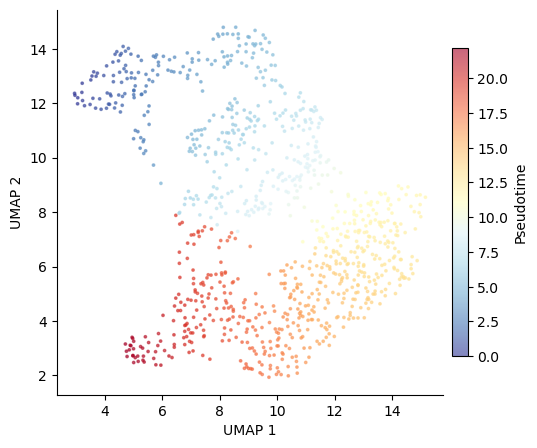

In [12]:
import matplotlib.pyplot as plt

umap_coords = adata_rna.obsm['X_umap'] 
pseudotime = adata_rna.obs['pseudotime'].values

fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    c=pseudotime, cmap='RdYlBu_r',
    s=3, alpha=0.6, rasterized=True
)
fig.colorbar(sc, ax=ax, label='Pseudotime', shrink=0.8, pad=0.02)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.spines[['top','right']].set_visible(False)


## processed pseudotime

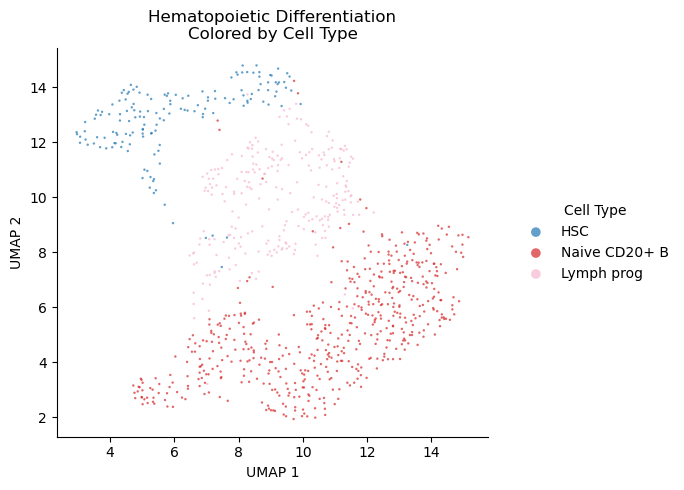

In [10]:
# 1. 提取坐标和细胞类型数据
umap_coords = adata_rna.obsm['X_umap']
cell_types = adata_rna.obs['cell_type']  # 假设列名是 'cell_type'

unique_cell_types = cell_types.unique()

cmap = plt.get_cmap('tab20')
color_dict = {ct: cmap(i / len(unique_cell_types)) for i, ct in enumerate(unique_cell_types)}

fig, ax = plt.subplots(figsize=(7, 5))  

for ct in unique_cell_types:
    mask = (cell_types == ct)
    ax.scatter(
        umap_coords[mask, 0], umap_coords[mask, 1],
        color=color_dict[ct],     # 指定颜色
        label=ct,                 # 指定图例名称
        s=3, alpha=0.7, rasterized=True, edgecolors='none'
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Hematopoietic Differentiation\nColored by Cell Type')
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), # 放在右侧外部
    frameon=False, 
    title='Cell Type',
    markerscale=4 
)

plt.tight_layout()

## Origin umap

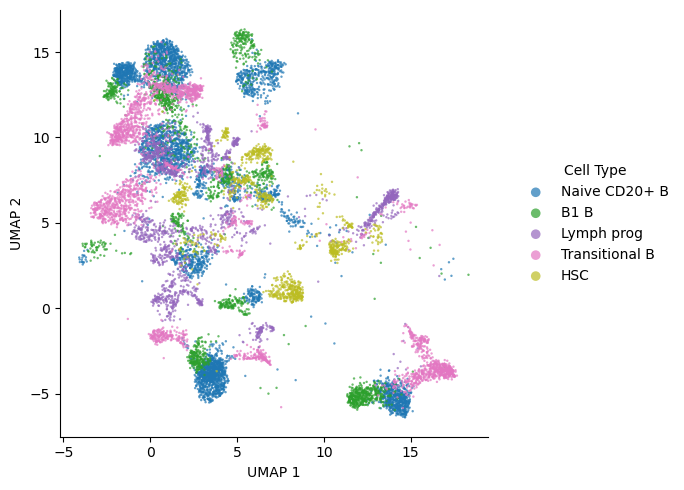

In [6]:
adata_rna_origin = ad.read_h5ad(data_path + 'rna_origin.h5ad')

def self_umap(adata_rna):
    umap_coords = adata_rna.obsm['GEX_X_umap']
    cell_types = adata_rna.obs['cell_type']  # 假设列名是 'cell_type'

    unique_cell_types = cell_types.unique()

    cmap = plt.get_cmap('tab20')
    color_dict = {ct: cmap(i / len(unique_cell_types)) for i, ct in enumerate(unique_cell_types)}

    fig, ax = plt.subplots(figsize=(7, 5))  

    for ct in unique_cell_types:
        mask = (cell_types == ct)
        ax.scatter(
            umap_coords[mask, 0], umap_coords[mask, 1],
            color=color_dict[ct],     # 指定颜色
            label=ct,                 # 指定图例名称
            s=3, alpha=0.7, rasterized=True, edgecolors='none'
        )

    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        loc='center left', 
        bbox_to_anchor=(1.05, 0.5), # 放在右侧外部
        frameon=False, 
        title='Cell Type',
        markerscale=4 
    )

    plt.tight_layout()
    
self_umap(adata_rna_origin)

## Pseudotime distribution

/tmp/ipykernel_58932/3689834955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


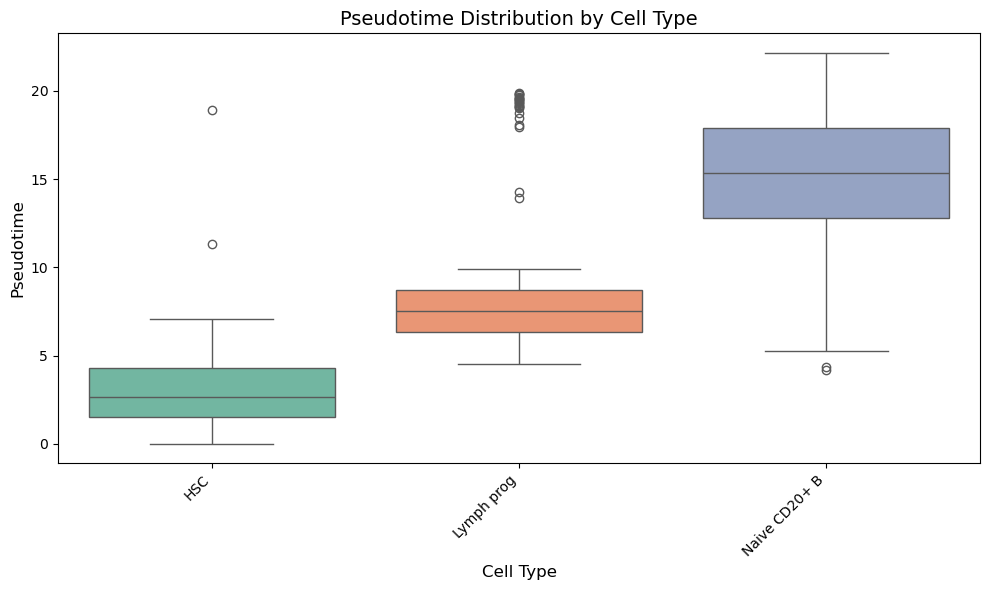

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置画布大小，确保有足够的空间展示所有的类别（可根据类别数量自行调整）
plt.figure(figsize=(10, 6))

# 2. 绘制箱线图
# 直接将 adata_rna.obs 传给 data 参数
sns.boxplot(
    data=adata_rna.obs, 
    x="cell_type",      # X轴：细胞类型
    y="pseudotime",     # Y轴：伪时间
    palette="Set2"      # 使用一个柔和的调色板（可选参数）
)

# 3. 美化图表
plt.title("Pseudotime Distribution by Cell Type", fontsize=14)
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Pseudotime", fontsize=12)

# 如果你的细胞类型名称（如 "ID2-hi myeloid prog"）比较长，
# 建议旋转 X 轴标签，防止文字相互重叠看不清
plt.xticks(rotation=45, ha="right")

# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout() 

# 4. 显示（或保存）图像
plt.show()
# 如果你想保存到本地，可以把 plt.show() 替换为：
# plt.savefig("pseudotime_boxplot.pdf", dpi=300)

# Test